In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Model using step-function HOD
## Define parameters

In [200]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

In [6]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [7]:
Delta = 200
delta_c = 1.686

In [8]:
hmf = ccl.halos.MassFuncTinker10()

In [9]:
NSIDE = 64

In [10]:
M_max = 15

## Define functions

In [11]:
def a_median(tab_datahi_mask_zbin0, key_zbin0 = ''):
    return 1/(1+np.median(tab_datahi_mask_zbin0['redshift_quaia'+key_zbin0]))

In [12]:
def b_qso(xi_qq, xi_mm, f):
    
    return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3

In [13]:
def nu(M, delta_c = delta_c, a = 1, cosmo = cosmo_planck18):
    
    sigma = cosmo.sigmaM(M, a = a)
   
    return delta_c/sigma

In [14]:
def n_g_theory(bins, n_total, a = 1, cosmo = cosmo_planck18, hmf = hmf, recenter = True):

    if recenter == True:
        bins = quaia.recenter(bins)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3
    n_g = nm/(bins*np.log(10))*n_total
    n_g[np.isnan(n_g)]=0
    
    return n_g, nm

def bias(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter)
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
    n_g = np.trapz(n_g, bins)
    dn_dm = nm/(bins*np.log(10))

    b1_E_tinker = b1_E_func(nu(bins, a = a, cosmo = cosmo), mod = mod)

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    return bias_function(n_g, integrand, b1_E_tinker, bins, recenter = recenter), n_g

In [15]:
def b1_E_func(nu, Delta = Delta, delta_c = delta_c, mod = False):

    delta_c = 1.686
    
    if mod == False:
        y = np.log10(Delta)
        A =  1.0+0.24*y*np.exp(-(4/y)**4)
        a = 0.44*y-0.88
        B = 0.183
        b =  1.5
        C = 0.019+0.107*y+0.19*np.exp(-(4/y)**4)
        c = 2.4
        
    else:
        A =  1.0
        a = 0.0906
        B = -4.5002
        b =  2.1419
        C = 4.9148
        c = 2.1419
        
    return 1-A*nu**a/(nu**a+delta_c**a)+B*nu**b+C*nu**c # Jose et al
    
def bias_function(n_g, integrand, b, bins, recenter = True):
    
    if recenter == True:
        print('recentering')
        bins = quaia.recenter(bins)
        
    return 1/n_g*np.trapz(integrand*b, bins)

In [16]:
def cf_2h(bins, n_m, a, cosmo, cf_matter, recenter = True):
    
    b_q, n_g = bias(bins, n_m, a, cosmo, recenter = recenter)
    return b_q**2*cf_matter, b_q

In [17]:
def M(bins, n_m, a = 1, cosmo = cosmo_planck18, mod = False, recenter = True, hmf = hmf):

    n_g, nm = n_g_theory(bins, n_m, a = a, cosmo = cosmo, recenter = recenter, hmf = hmf)
    if recenter == True:
        n_g = np.trapz(n_g, quaia.recenter(bins))
        dm = np.diff(bins) 
        dn_dm = nm/(quaia.recenter(bins)*np.log(10))
    else:
        n_g = np.trapz(n_g, bins)
        dn_dm = nm/(bins*np.log(10))

    n_m[~np.isfinite(n_m)]=0 
    integrand = dn_dm*n_m
    integrand[np.isnan(integrand)]=0
    
    if recenter == True:
        return bias_function(n_g, integrand, quaia.recenter(bins), bins, recenter = recenter), n_g
    else:
        return bias_function(n_g, integrand, bins, bins, recenter = recenter), n_g

In [18]:
def HOD(bins, M_min, fduty):

    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=M_min]=fduty

    return n_m

In [19]:
def n_DM(cosmo, a, M_min, hmf = hmf, M_max = M_max, N = 79): #16.8
    
    bins = np.logspace(M_min, M_max, N)
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 #/u.Mpc**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.trapz(dn_dm, bins)

# Implement halo model
## Plot HOD: $\langle N(M) \rangle = \begin{cases}f_{duty} & M\geq M_{min} \\ 0 & M<M_{min}\end{cases}$
### At fixed $f_{duty}$ and $M_{min}$

In [20]:
bins = np.logspace(9, M_max, 79)

In [87]:
# M_min_array = [12.86, 12.74, 12.79, 12.82]
M_min_array = [11.94, 11.98, 11.97, 12.07]

In [144]:
# fduty = [0.018, 0.022, 0.056, 0.071]
fduty = [0.002, 0.002, 0.003, 0.002]
n_m_array = []
for i in z_array:        
    n_m=np.zeros(np.shape(quaia.recenter(bins)))
    n_m[quaia.recenter(bins)>=10**M_min_array[i]]=fduty[i]
    n_m_array.append(n_m)

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_247429/3618045427.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))
/tmp/ipykernel_247429/3618045427.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$M (M_\odot)$')


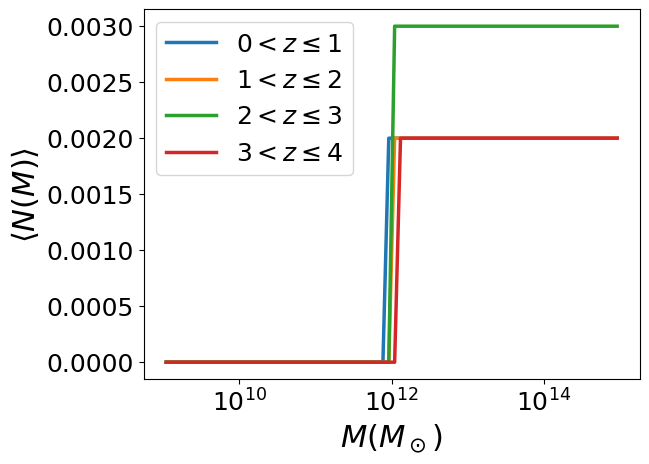

In [145]:
for i in z_array:
        
    plt.plot(quaia.recenter(bins), n_m_array[i], linewidth = 2.5, label = '${:.0f}<z \leq{:.0f}$'.format(i, i+1))

plt.xscale('log')
plt.xlabel('$M (M_\odot)$')
plt.ylabel(r'$\langle N(M) \rangle$')
plt.legend()
plt.show()

In [146]:
n_m_array, bins_M_min = [], []
for i in z_array:   
    bins_i = np.logspace(M_min_array[i], M_max, 79)
    n_m=np.ones(np.shape(bins_i))*fduty[i]
    n_m_array.append(n_m)
    bins_M_min.append(bins_i)

In [147]:
n_m_array_2D = []
for i in z_array:

    n_m_array_2D.append([])
    
    for j in range(len(bins)):
        
        n_m=np.ones(np.shape(bins))*fduty[i]
        n_m_array_2D[i].append(n_m)

## Calculate $b_{\mathrm{qq}}(s,z)=\sqrt{\frac{\xi^{(s)}_{\mathrm{qq}}(s)}{\xi^{(r)}_\mathrm{mm}(r)}-\frac{4 \Omega_{\mathrm{m}}^{1.2}(z)}{45}}-\frac{\Omega_{\mathrm{m}}^{0.6}(z)}{3}$
### Use a 50th percentile mask

In [148]:
bins_M_min_array = [np.logspace(np.log10(bins[j]), M_max, 79) for j in range(len(bins))]

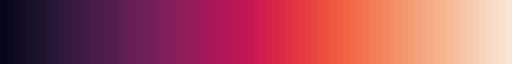

In [149]:
cmap = sns.color_palette("rocket", n_colors = len(bins))
palette = matplotlib.colors.ListedColormap(cmap)
palette

# Calculate derived parameters
## Plot b(z)

In [150]:
def b_eboss(z):
    
    return 0.278*((1+z)**2-6.565) + 2.393

def b_quaia(b_0, a, cosmo = cosmo_planck18): #quaia):
    
    return b_0/ccl.growth_factor(cosmo, a)

In [151]:
b_cf20 = np.load('../results/b_cf20_planck18.npy')
b_wp20 = np.load('../results/b_wp20_planck18.npy')

## Calculate number density as $n_q \approx \int_0^{\infty} d M \frac{d n}{d M}\langle N(M)\rangle$

In [152]:
tab_datahi_mask_zbins, selfunc_hi_bins = [], []
for j in z_array:
    
    tab_datahi_mask_zbin0, _, _, _, _, _, selfunc_hi_bin0, _, _ = quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)
    tab_datahi_mask_zbins.append(tab_datahi_mask_zbin0['redshift_quaia'])
    selfunc_hi_bins.append(selfunc_hi_bin0)

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508
Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


In [153]:
LMC = SkyCoord(['05 23 34.6 -69 45 22'], unit=(u.hourangle, u.deg)) #https://simbad.u-strasbg.fr/simbad/sim-id?Ident=Large+Magellanic+Cloud

In [154]:
LMC_radius = 9*u.deg

In [155]:
SMC = SkyCoord(['00 52 38.0 -72 48 01'], unit=(u.hourangle, u.deg)) # https://simbad.u-strasbg.fr/simbad/sim-id?Ident=small+Magellanic+Cloud

In [156]:
SMC_radius = 5*u.deg

In [157]:
n_q, n_q_err, V_eff, N_q = [], [], [], []

for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    print(f_sky) # f_sky)
    V = f_sky*(Planck18.comoving_volume(z_bins[j+1])-Planck18.comoving_volume(z_bins[j]))*Planck18.h**3/u.h**3
    N_q.append(N)
    n_q.append(N/V.value)
    n_q_err.append(np.sqrt(N)/V.value) # Poisson error
    V_eff.append(V)
    
n_q

0.3812326432060453
0.39892696555786405
0.4240188533529075
0.4349358620974798


[1.1560583824125186e-05,
 8.122876991671759e-06,
 3.0941145087989882e-06,
 2.7241521338797804e-07]

In [158]:
fduty_err_hi = 0.002, 0.001, 0.008, 0.077
fduty_err_lo = 0.002, 0.001, 0.007, 0.034

In [159]:
def n_q_theory_err(n_dm, fduty_err, M_min, a, M_min_err, hmf = hmf, cosmo = cosmo_planck18): #quaia):
    
    nm = hmf(cosmo, bins, a)/cosmo['h']**3 # convert to h/Mpc**3
    dn_dm = nm/(bins*np.log(10))
    
    return np.sqrt(n_dm**2*fduty_err**2+(fduty_err*hmf(cosmo, 10**M_min, a))**2*M_min_err**2)

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [160]:
# Create the bins array
offset = 2.5
delta_max = 64
delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80+delta_max*offset # 200
nbins = 20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([  2.5,   5. ,   7.5,  10. ,  12.5,  15. ,  17.5,  20. ,  22.5,
         25. ,  27.5,  30. ,  32.5,  35. ,  37.5,  40. ,  42.5,  45. ,
         47.5,  50. ,  52.5,  55. ,  57.5,  60. ,  62.5,  65. ,  67.5,
         70. ,  72.5,  75. ,  77.5,  80. ,  82.5,  85. ,  87.5,  90. ,
         92.5,  95. ,  97.5, 100. , 102.5, 105. , 107.5, 110. , 112.5,
        115. , 117.5, 120. , 122.5, 125. , 127.5, 130. , 132.5, 135. ,
        137.5, 140. , 142.5, 145. , 147.5, 150. , 152.5, 155. , 157.5,
        160. , 162.5, 165. , 167.5, 170. , 172.5, 175. , 177.5, 180. ,
        182.5, 185. , 187.5, 190. , 192.5, 195. , 197.5, 200. , 202.5,
        205. , 207.5, 210. , 212.5, 215. , 217.5, 220. , 222.5, 225. ,
        227.5, 230. , 232.5, 235. , 237.5, 240. ]),
 array([  3.75,   6.25,   8.75,  11.25,  13.75,  16.25,  18.75,  21.25,
         23.75,  26.25,  28.75,  31.25,  33.75,  36.25,  38.75,  41.25,
         43.75,  46.25,  48.75,  51.25,  53.75,  56.25,  58.75,  61.25,
         63.75,  66.25

In [161]:
pimax = 80 # 40 # 5000.0 # 40.0\

In [162]:
dpi = 0.01
pibins = np.arange(0, pimax+1, dpi)

## Compute the maximum number of jackknife regions

In [163]:
for j in z_array:
    
    N = len(tab_datahi_mask_zbins[j])
    cp = np.percentile(selfunc_hi_bins[j], mask*100)
    selfunc_mask = selfunc_hi_bins[j]>=cp
    theta, phi = hp.pix2ang(NSIDE, range(len(selfunc_hi_bins[j])), lonlat=True)
    c = SkyCoord(ra=theta*u.degree, dec=phi*u.degree)
    LMC_idx, _, _, _ = SkyCoord.search_around_sky(LMC, c, LMC_radius)
    SMC_idx, _, _, _ = SkyCoord.search_around_sky(SMC, c, SMC_radius)
    MC_idx = np.append(LMC_idx,SMC_idx)
    MC_mask = np.full_like(range(len(selfunc_hi_bins[j])), True, dtype = bool)
    MC_mask[MC_idx] = False
    f_sky = 1/(4*np.pi)*np.sum(selfunc_hi_bins[j][selfunc_mask & MC_mask]*hp.nside2pixarea(NSIDE))
    V = f_sky*(Planck18.comoving_volume(j+1)-Planck18.comoving_volume(j))*Planck18.h**3/u.h**3
    V_jackknife = f_sky*(4/3*np.pi*(rmax**3))*V.unit
    print(np.int(V/V_jackknife), (V/25)**(1/3))

877 918.4012950330948 Mpc / h
2473 1317.3134853785514 Mpc / h
2813 1403.241459100361 Mpc / h
2666 1390.0450834650237 Mpc / h


In [164]:
wp_chi2, wp_matter_chi2, rpavg_chi2 = [], [], []
b_wp_chi2 = []
a_zbin, b_wp_q = [], []
rpmask = []
H0 = Planck18.H0 # cosmo_planck18['H0'] * u.km/u.s/u.Mpc
    
for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask*100, percentile = True)

    # quasar correlation function
    wp_zbin_i, rpavg_zbin_i = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, 
                                                                  rbins = rbins, nbins = nbins, pimax = pimax, Om0 = Planck18.Om0, h = Planck18.h)
    wp_chi2.append(wp_zbin_i)
    rpavg_chi2.append(rpavg_zbin_i)

    # scale factor
    a = a_median(tab_datahi_mask_zbin0)
    a_zbin.append(a)

    # matter correlation function   
    s = np.sqrt(np.sum(np.meshgrid(np.array(rpavg_zbin_i)**2, quaia.recenter(pibins)**2), axis = 0))
    s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(H0))
        
    xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo_planck18, r=np.ravel(s_Mpc), a=a_median(tab_datahi_mask_zbin0))
    wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)
    wp_matter_chi2.append(wp_matter_zbin_i)        

    # effective bias 
    b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
    b_wp_chi2.append(b)

    # qso bias
    b_wp_q.append(b_qso(wp_zbin_i, wp_matter_zbin_i, ccl.growth_rate(cosmo_planck18, a)))
    
    rpmask.append((np.array(rpavg_zbin_i) >= 30) & (np.array(rpavg_zbin_i) <= 80))

Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0: 0.31              223881 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_247429/1007250612.py:33: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_247429/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0: 0.28              464213 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_247429/1007250612.py:33: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_247429/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0: 0.25              213734 vs 286508


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_247429/1007250612.py:33: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_247429/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


Pixels masked by MC but not already by selfunc: 350
G20.5_zmin3.0zmax4.6: 0.22              28436 vs 36458


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/tmp/ipykernel_247429/1007250612.py:33: RuntimeWarning: invalid value encountered in sqrt
  b = np.sqrt(wp_zbin_i/wp_matter_zbin_i)
/tmp/ipykernel_247429/4043121211.py:3: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(xi_qq/xi_mm-4*f**2/45)-f/3


# Perform nested sampling with dynesty

In [165]:
# Define the dimensionality of our problem.
ndim = 2

In [166]:
def wp_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, rpbins, pibins, recenter = True, rpmask = True):

    if not isinstance(wp_matter_zbin_i, np.ndarray):
        
        print('computing wp_matter')
        
        # matter correlation function    
        if isinstance(rpmask, bool):
            rpmask = [rpmask]*len(quaia.recenter(rpbins))
            
        s = np.sqrt(np.sum(np.meshgrid(quaia.recenter(rpbins)[rpmask]**2, quaia.recenter(pibins)**2), axis = 0))
        s_Mpc = (s*u.Mpc/cu.littleh).to(u.Mpc, cu.with_H0(cosmo['h']* 100 * u.km/u.s/u.Mpc))

        xirppi_zbin_i = ccl.correlations.correlation_3d(cosmo, r=np.ravel(s_Mpc), a=a)
        wp_matter_zbin_i = 2*np.trapz(np.reshape(xirppi_zbin_i, np.shape(s_Mpc)), quaia.recenter(pibins), axis = 0)

    return cf_2h(bins, n_m, a, cosmo, wp_matter_zbin_i, recenter = recenter)

In [167]:
# Define our 3-D correlated multivariate normal log-likelihood.
# C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, j)) # very good
# C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck_MC.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) 

ix_grid = np.ix_(rpmask[j], rpmask[j])
    
def loglike(x, a, wp_matter, rpbins, pibins, C, wp, n_q, nbins, cosmo = cosmo_planck18, error = 0.05):
    
    f_duty, M_min = x
    
    bins_m = np.logspace(M_min, M_max, 79)
    n_m=np.ones(np.shape(bins_m))*10**f_duty
        
    wp_2h_zbin, _ = wp_2h(bins_m, n_m, a, cosmo, wp_matter, rpbins, pibins, recenter = False)
    delta = wp-wp_2h_zbin
    
    Cinv = np.linalg.inv(C)
    lnorm = -0.5 * (np.log(2 * np.pi) * nbins +
                    np.log(np.linalg.det(C)))
    
    n_q_theory = M(bins_m, n_m, a = a, cosmo = cosmo, recenter = False)[1]
    penalty = np.abs(n_q_theory-n_q)/n_q
    if penalty > error:
        penalty = np.inf
    # penalty = 0.5*((n_q_theory-n_q)/(error*n_q))**2
    
    return -0.5 * np.dot(delta, np.dot(Cinv, delta)) + lnorm - penalty

In [168]:
def ptform(u):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u 

    # Uniform from 0 to 1
    x[0] =  6* u[0] - 6 # scale and shift to [-6., 0.)

    # Uniform from 9 to 15
    x[1] = 6 * u[1] + 9  # scale and shift to [9., 15.)

    return x

In [169]:
# initialize our nested sampler
sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], wp_matter_chi2[j][rpmask[j]], rbins, pibins, C[ix_grid], wp_chi2[j][rpmask[j]], n_q[j], nbins], logl_kwargs = {'error':0.05})

In [170]:
# run the sampler with checkpointing
sampler.run_nested(dlogz = 0.005)
results = sampler.results

3291it [00:17, 189.79it/s, +500 | bound: 16 | nc: 1 | ncall: 36514 | eff(%): 10.526 | loglstar:   -inf < -140.187 <    inf | logz: -146.281 +/-    nan | dlogz:  0.000 >  0.005]


In [171]:
# Print out a summary of the results.
results.summary()

Summary
nlive: 500
niter: 3291
ncall: 8514
eff(%): 10.526
logz: -146.281 +/-  0.109


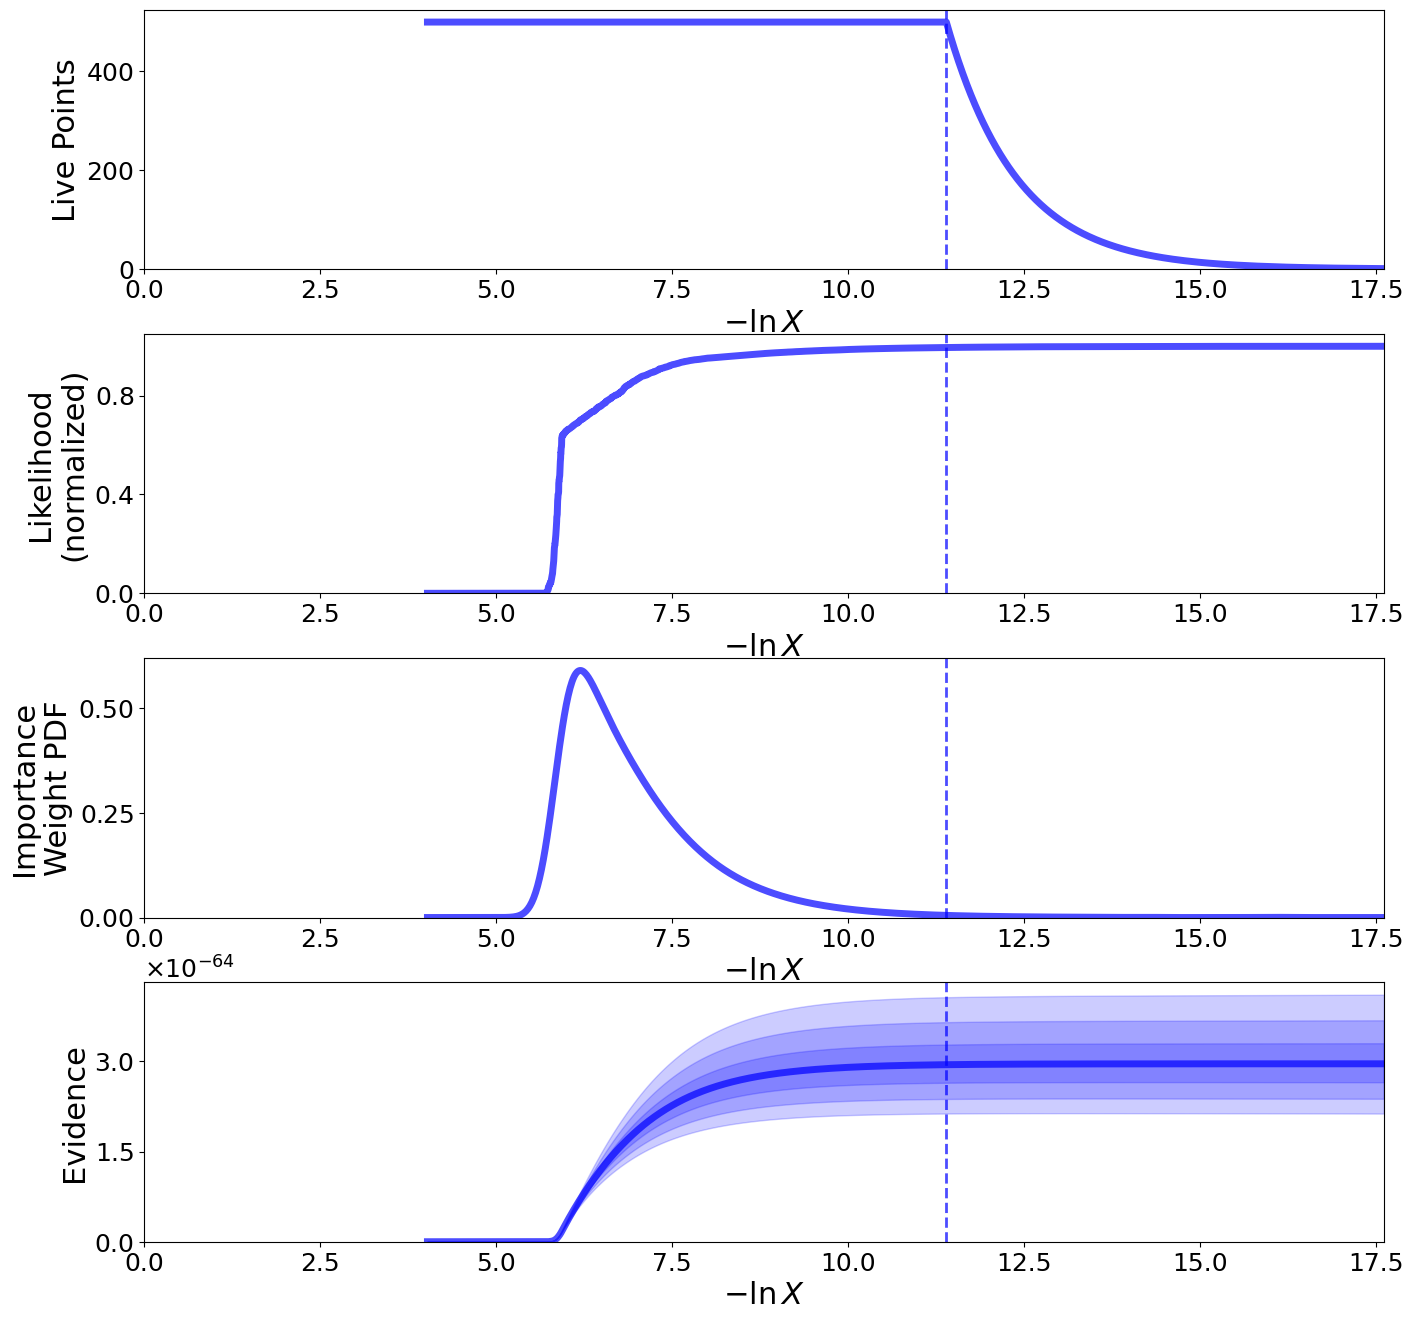

In [172]:
fig, axes = dyplot.runplot(results)  # summary (run) plot
fig.subplots_adjust(hspace=0.25)

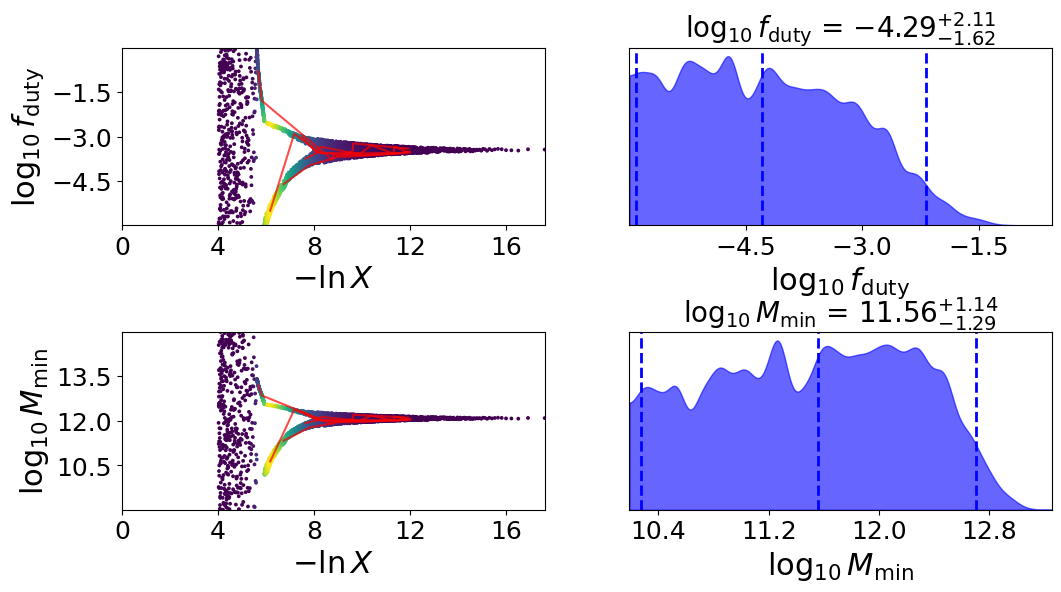

In [173]:
fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
fig.subplots_adjust(hspace=0.6)

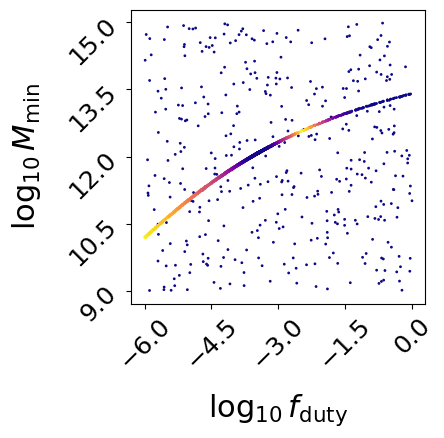

In [174]:
# initialize figure
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# plot initial run (res1; left)
fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                             kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))

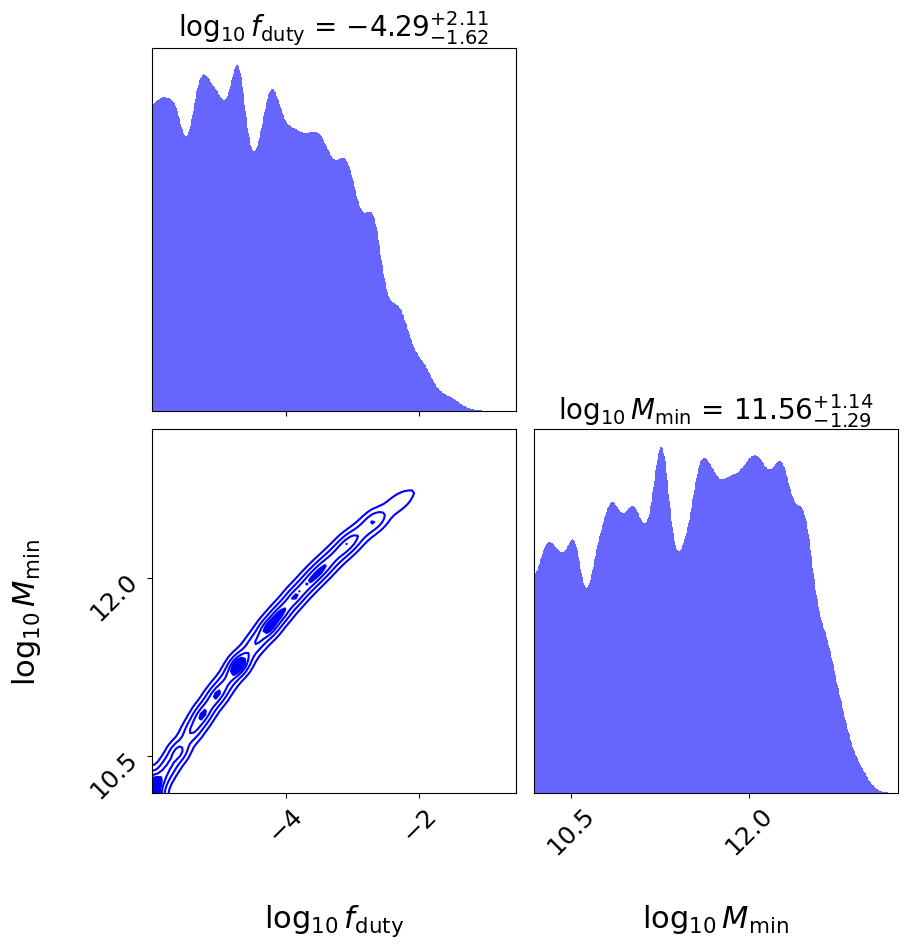

In [175]:
# # initialize figure
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# plot initial run (res1; left)
fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                           truth_color='black', show_titles=True,
                           max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))

In [176]:
samples, weights = results.samples, results.importance_weights()
mean, cov = dyfunc.mean_and_cov(samples, weights)
print(mean, cov)

[-4.24814959 11.5078106 ] [[1.16349669 0.76607935]
 [0.76607935 0.51122416]]


In [177]:
# Compute weighted quantiles
samples, weights = results.samples, results.importance_weights()

# Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
quantiles = [dyfunc.quantile(samples[:, i], [0.025, 0.5, 0.975], weights=weights) 
             for i in range(samples.shape[1])]
labels = ['log10(f_duty)', 'log10(M_min)']

for i, (lo, mid, hi) in enumerate(quantiles):
    print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")

log10(f_duty): -4.29 + 2.11/-1.62
log10(M_min): 11.56 + 1.14/-1.29


## Across all $z$

4374it [00:18, 239.71it/s, +500 | bound: 19 | nc: 1 | ncall: 29376 | eff(%): 16.879 | loglstar:   -inf < -88.356 <    inf | logz: -96.229 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4374
ncall: 9876
eff(%): 16.879
logz: -96.229 +/-  0.122
0<z<=1
log10(f_duty): -2.38 + 0.15/-0.18
log10(M_min): 12.39 + 0.14/-0.17



4304it [00:17, 245.84it/s, +500 | bound: 19 | nc: 1 | ncall: 26808 | eff(%): 18.261 | loglstar:   -inf < -79.993 <    inf | logz: -87.604 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4304
ncall: 9808
eff(%): 18.261
logz: -87.604 +/-  0.121
1<z<=2
log10(f_duty): -2.74 + 0.16/-0.18
log10(M_min): 12.06 + 0.13/-0.15



4263it [00:18, 224.46it/s, +500 | bound: 20 | nc: 1 | ncall: 33855 | eff(%): 14.280 | loglstar:   -inf < -97.450 <    inf | logz: -105.273 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 4263
ncall: 10855
eff(%): 14.280
logz: -105.273 +/-  0.122
2<z<=3
log10(f_duty): -2.61 + 0.22/-0.25
log10(M_min): 12.23 + 0.15/-0.17



3278it [00:16, 202.45it/s, +500 | bound: 17 | nc: 1 | ncall: 38689 | eff(%):  9.893 | loglstar:   -inf < -140.187 <    inf | logz: -146.316 +/-    nan | dlogz:  0.000 >  0.005]


Summary
nlive: 500
niter: 3278
ncall: 8689
eff(%):  9.893
logz: -146.316 +/-  0.110
3<z<=4
log10(f_duty): -4.29 + 1.29/-1.15
log10(M_min): 11.56 + 0.77/-0.88



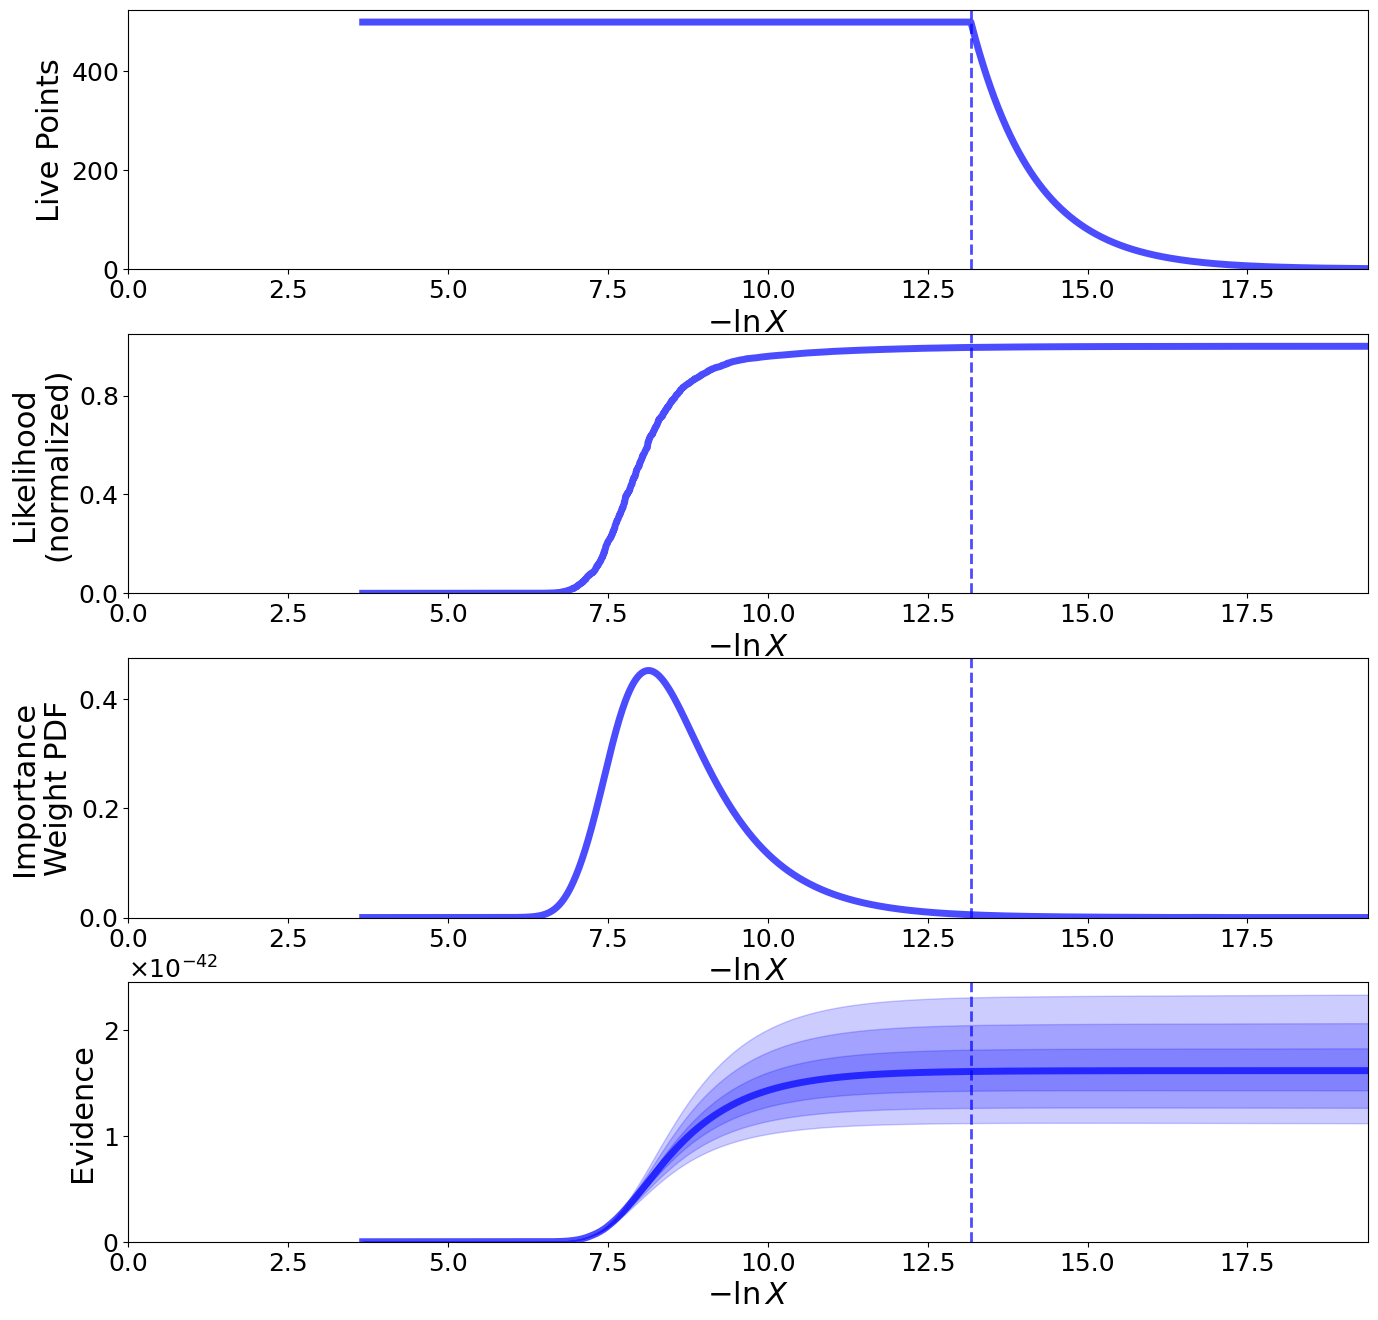

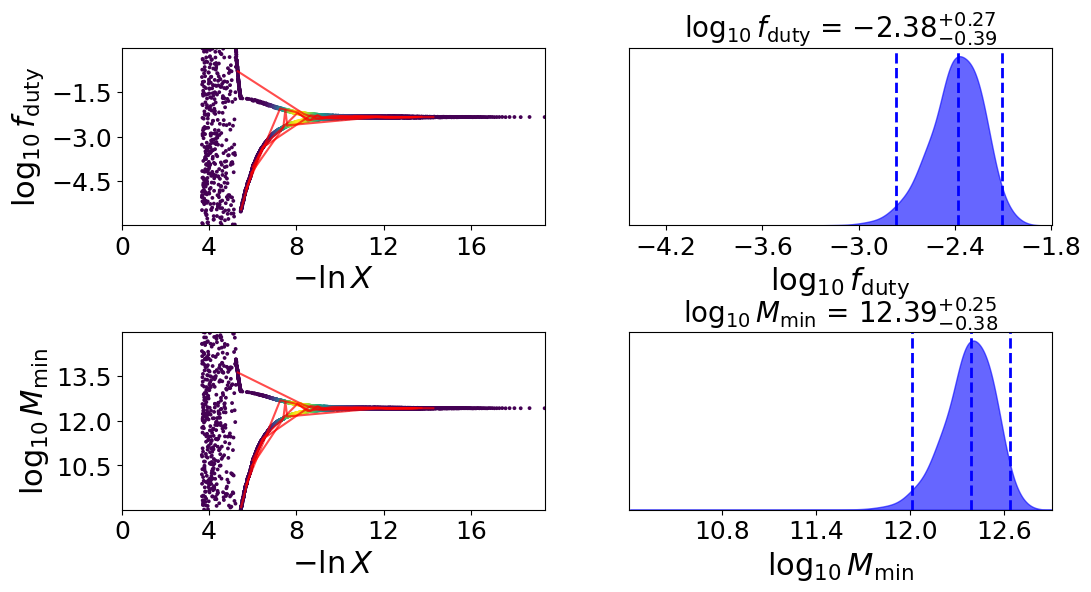

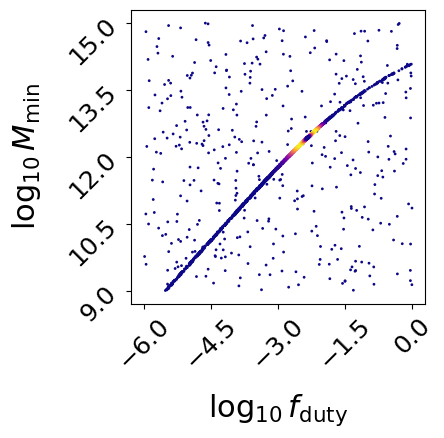

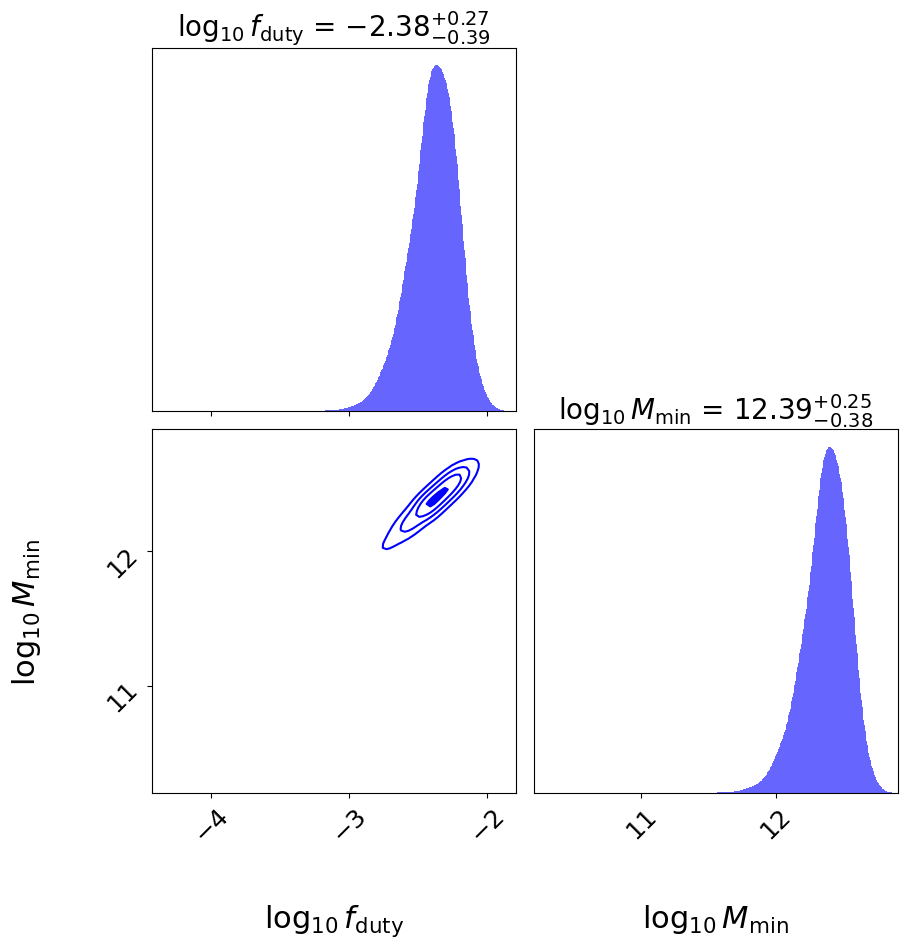

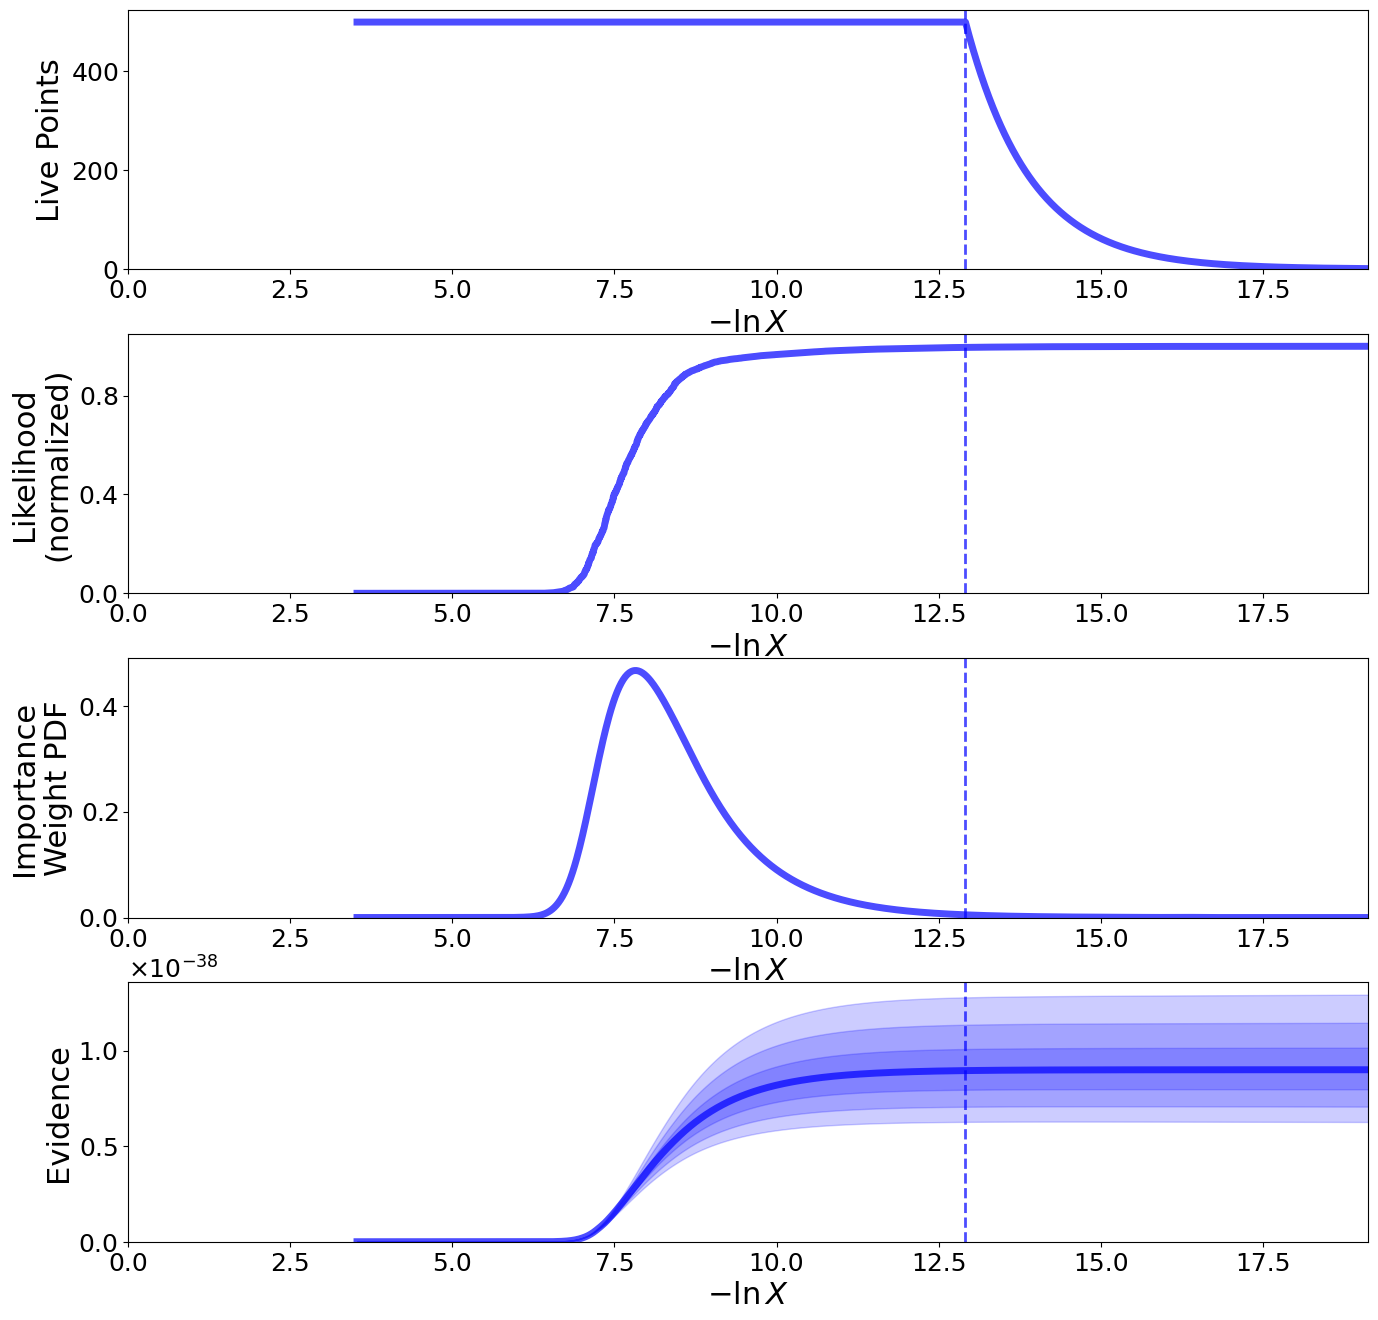

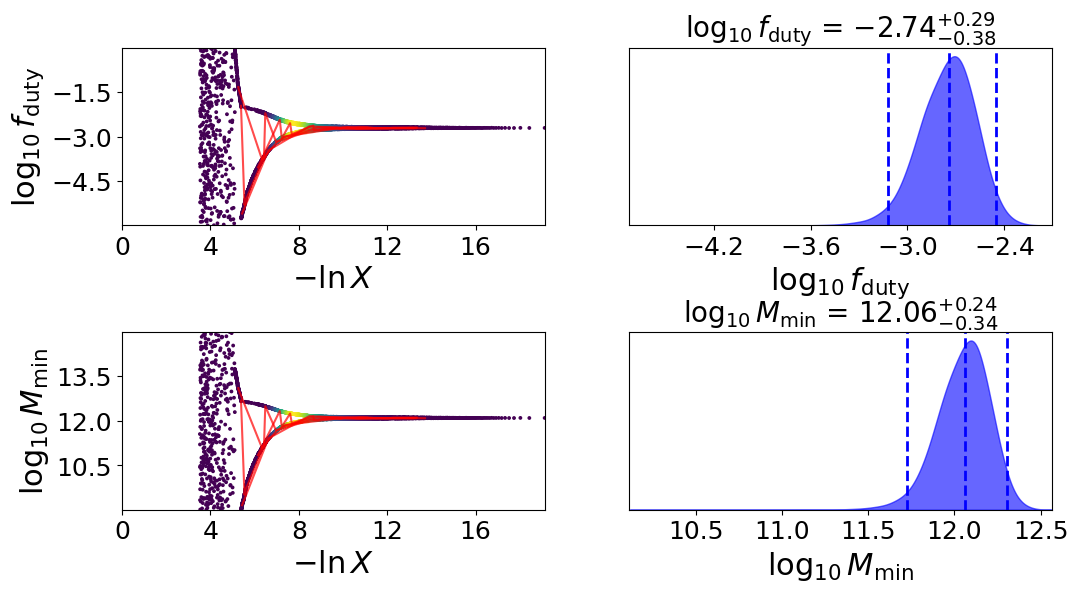

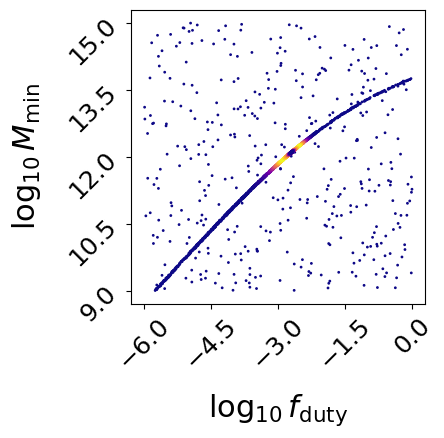

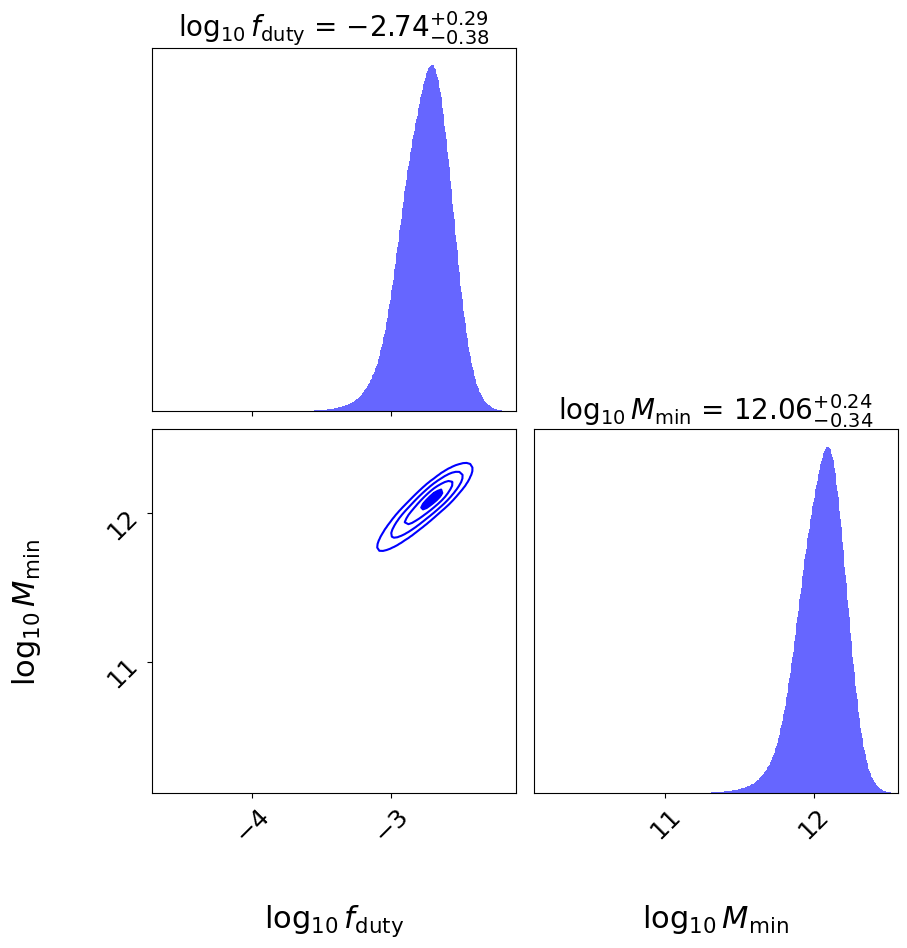

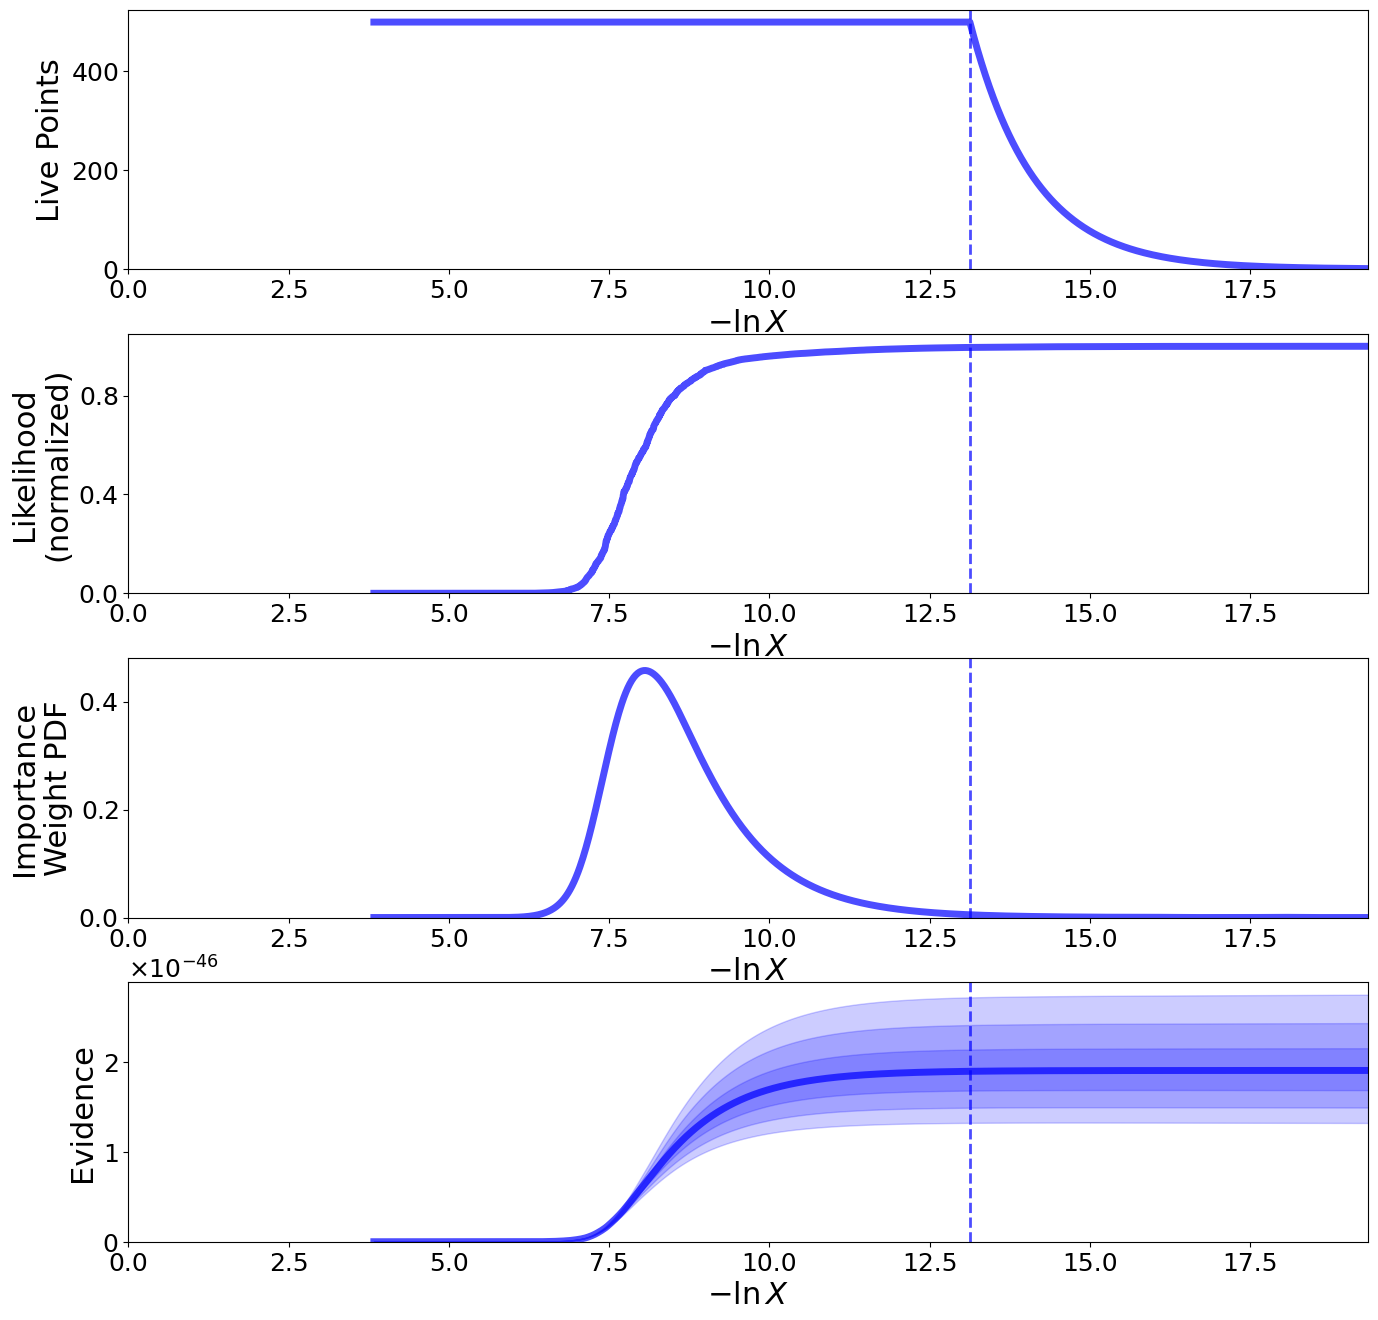

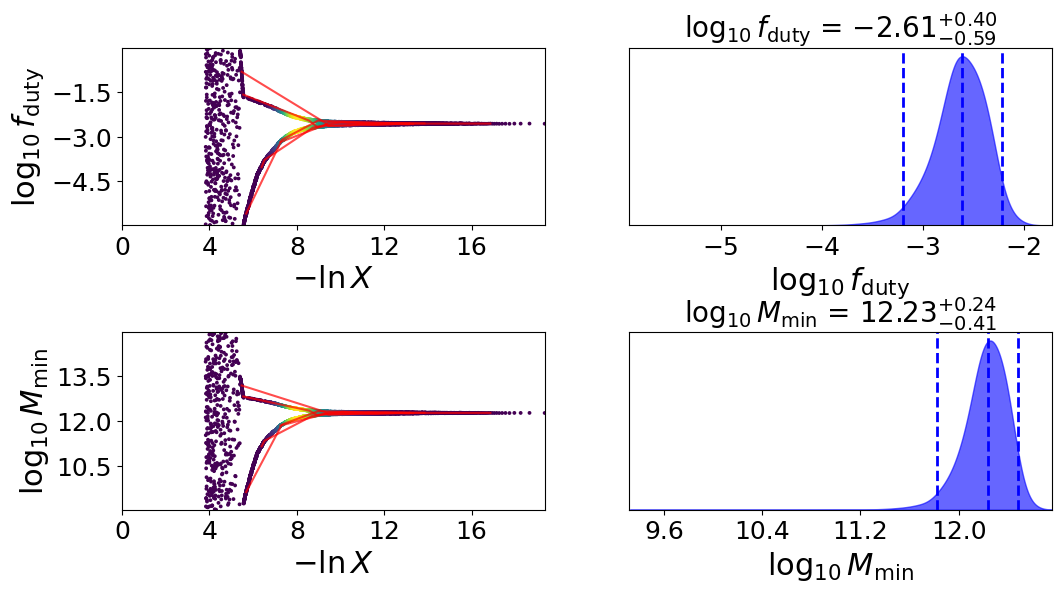

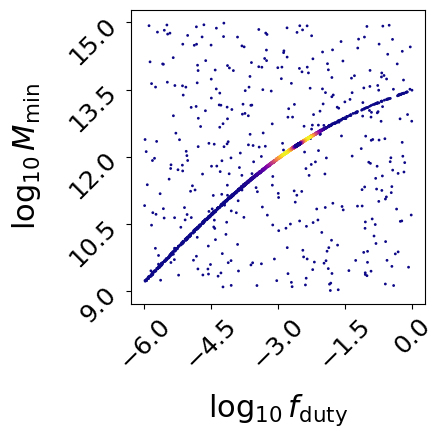

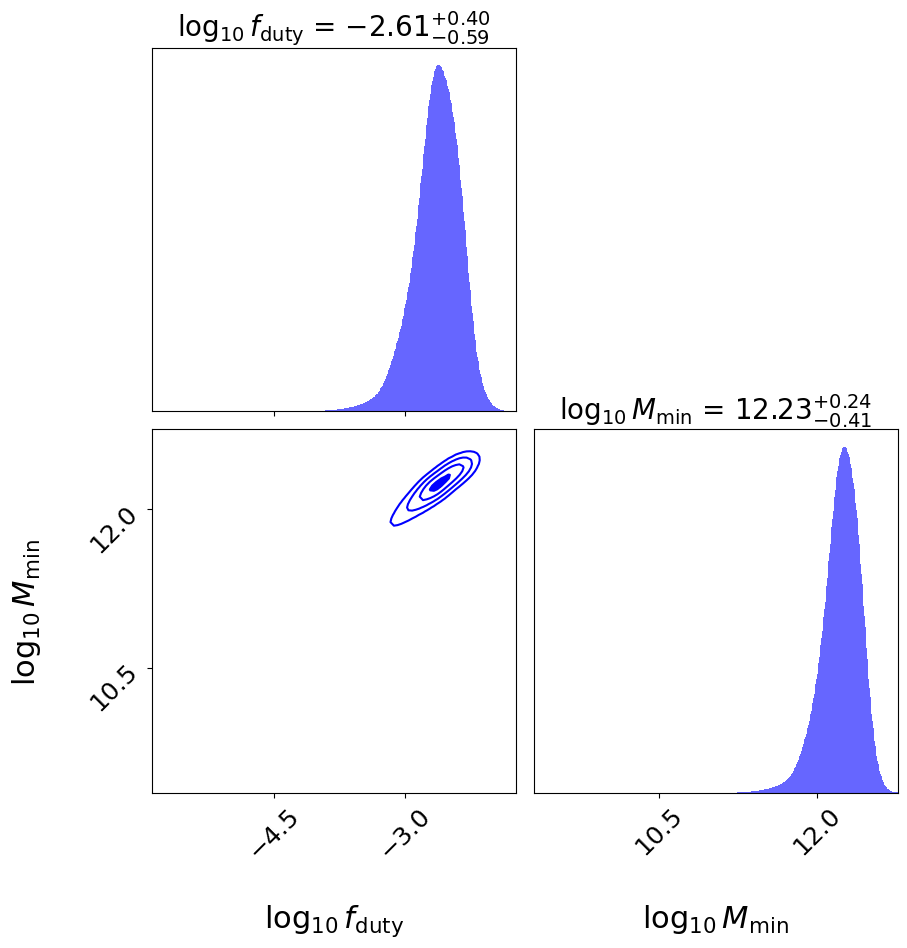

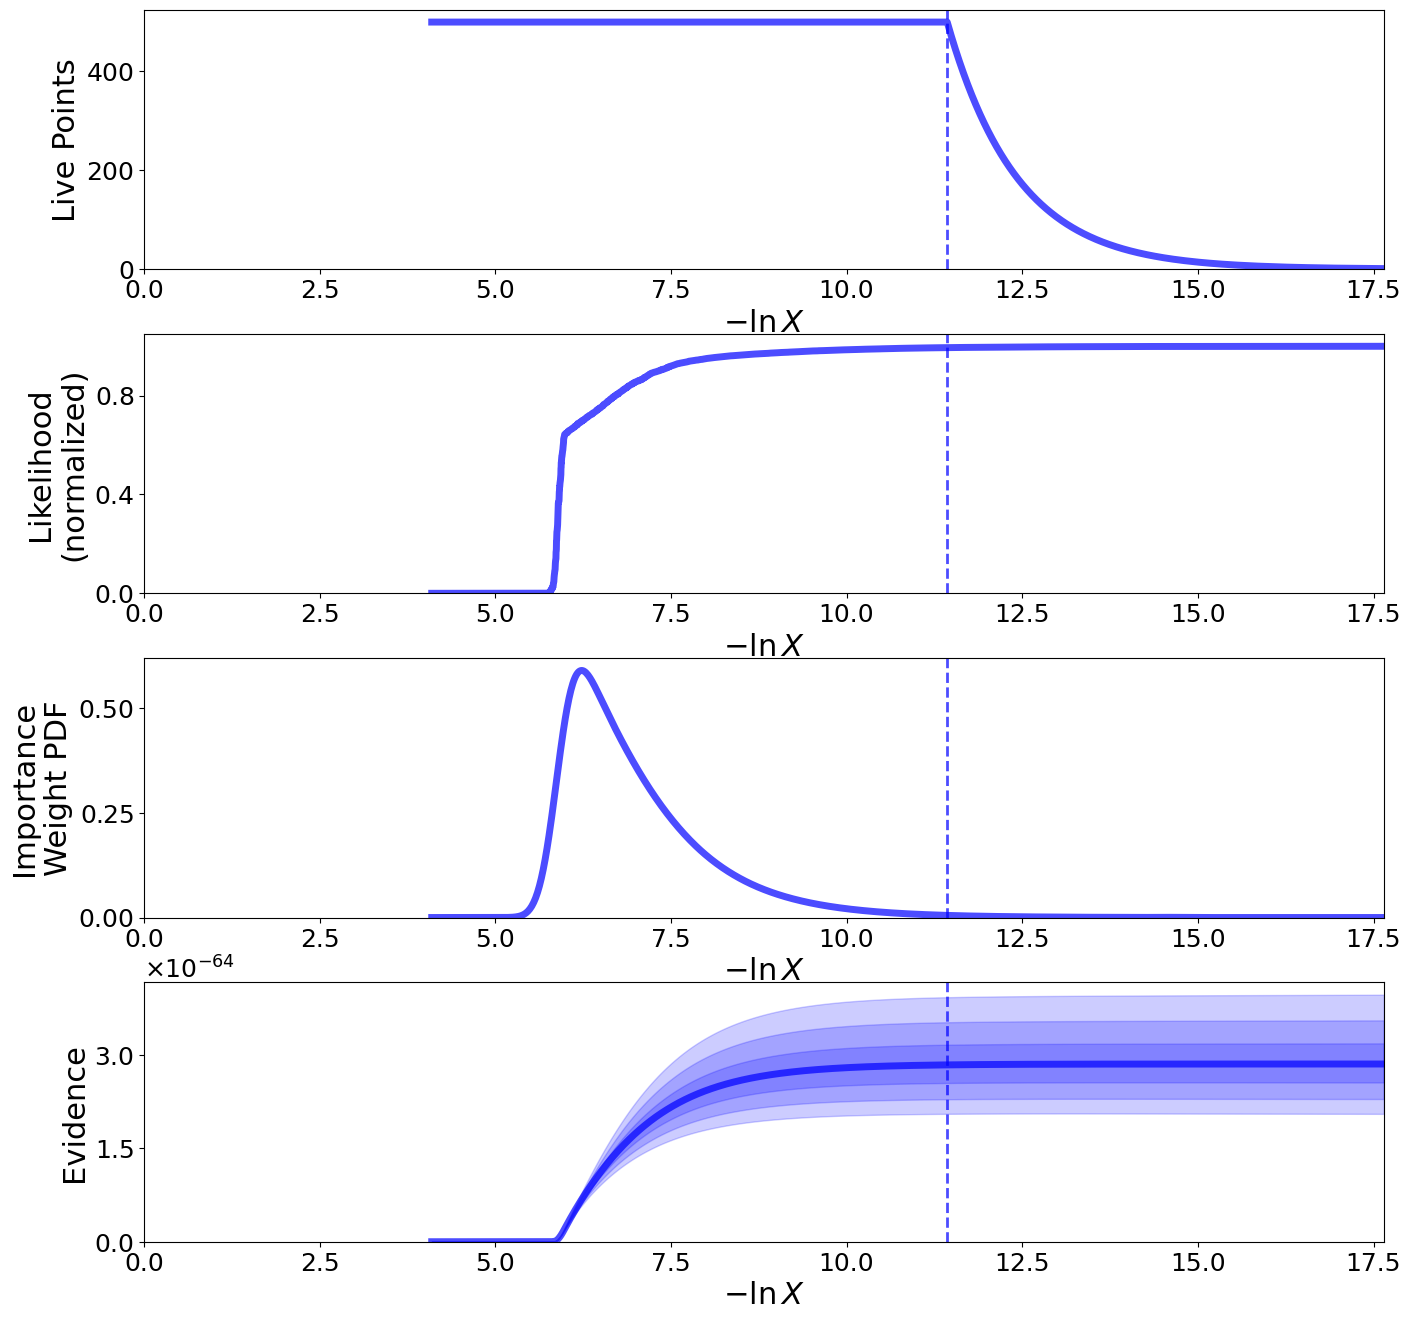

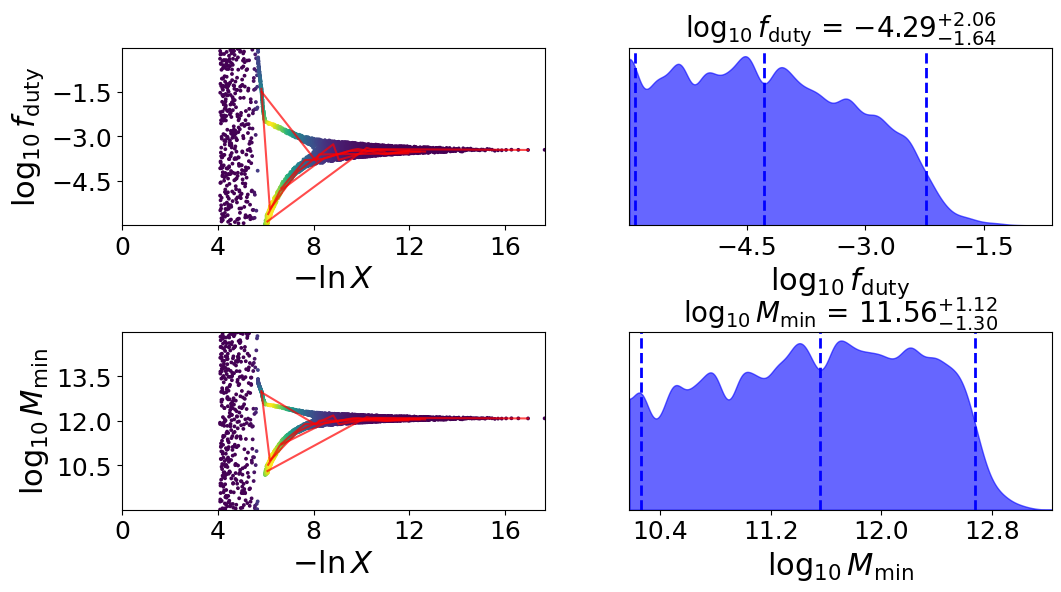

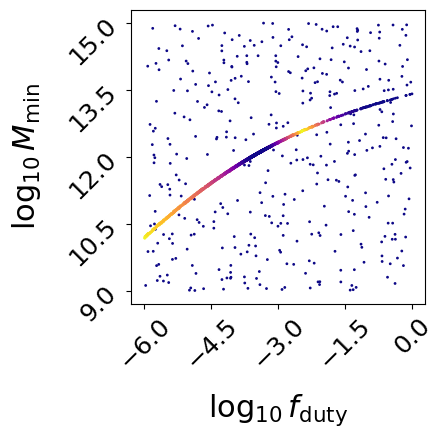

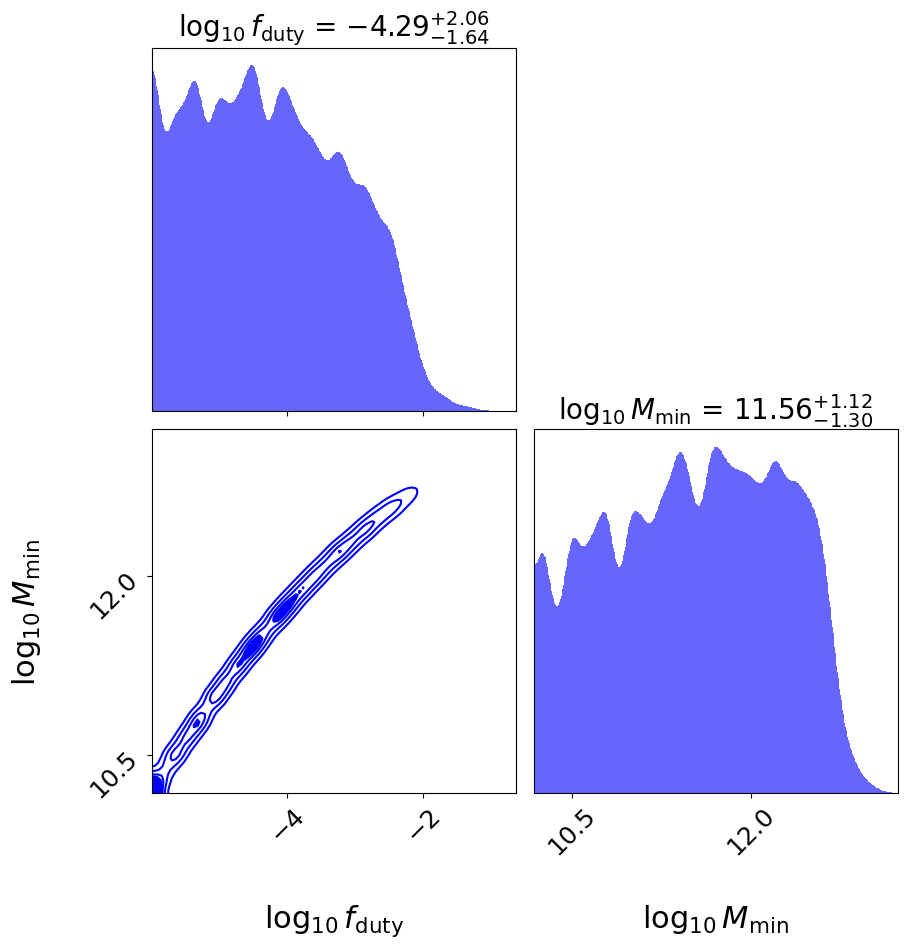

In [178]:
f_duty, M_min = [], []
# f_duty_hi, M_min_hi, f_duty_lo, M_min_lo = [], [], [], []
labels = ['log10(f_duty)', 'log10(M_min)']
err = {i: [] for i in labels}
f_duty_samples, M_min_samples = [], []
for j in z_array:
    
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, j))
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck_MC.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
    ix_grid = np.ix_(rpmask[j], rpmask[j])

    # initialize our nested sampler
    sampler = NestedSampler(loglike, ptform, ndim, logl_args=[a_zbin[j], wp_matter_chi2[j][rpmask[j]], rbins, pibins, C[ix_grid], wp_chi2[j][rpmask[j]], n_q[j], nbins], logl_kwargs = {'error':0.05})    
    
    # run the sampler with checkpointing
    sampler.run_nested(dlogz = 0.005)
    results = sampler.results
    
    # Print out a summary of the results.
    results.summary()
    
    fig, axes = dyplot.runplot(results)  # summary (run) plot
    fig.subplots_adjust(hspace=0.25)
    
    fig, axes = dyplot.traceplot(results, 
                             show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(5), labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'])
    fig.subplots_adjust(hspace=0.6)
    
    # initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerpoints(results, cmap='plasma',
                                 kde=False, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes))
    
    # initialize figure
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    # plot initial run (res1; left)
    fg, ax = dyplot.cornerplot(results, color='blue', truths=np.zeros(ndim),
                               truth_color='black', show_titles=True,
                               max_n_ticks=3, quantiles=None, labels=[r'$\log_{10}f_\mathrm{duty}$', r'$\log_{10} M_\mathrm{min}$'], fig=(fig, axes[:, :3]))

    samples, weights = results.samples, results.importance_weights()

    # Get median and 1-sigma (16th, 50th, 84th percentiles) for each parameter
    quantiles = [dyfunc.quantile(samples[:, i], [0.16, 0.5, 0.84], weights=weights) 
                 for i in range(samples.shape[1])]

    print('{}<z<={}'.format(j, j+1))
    for i, (lo, mid, hi) in enumerate(quantiles):
        print(f"{labels[i]}: {mid:.2f} + {hi-mid:.2f}/-{mid-lo:.2f}")
        err[labels[i]].append((lo, hi))
    print()
    
    equal_weight_samples = dyfunc.resample_equal(samples, weights)
    ind = np.random.choice(range(len(equal_weight_samples)), size = 1000, replace = False)
    f_duty_samples.append(equal_weight_samples[ind][:,0])
    M_min_samples.append(equal_weight_samples[ind][:,1])
    
    f_duty.append(quantiles[0][1])
    M_min.append(quantiles[1][1]) 

## Plot results

In [179]:
zbin = 1/np.array(a_zbin)-1

In [180]:
z_eff = [0.5, 1.5, 2.5, 3.5]

In [181]:
# M_min_giner = [11.94, 11.98, 11.97, 12.07]

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_247429/3507153454.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')


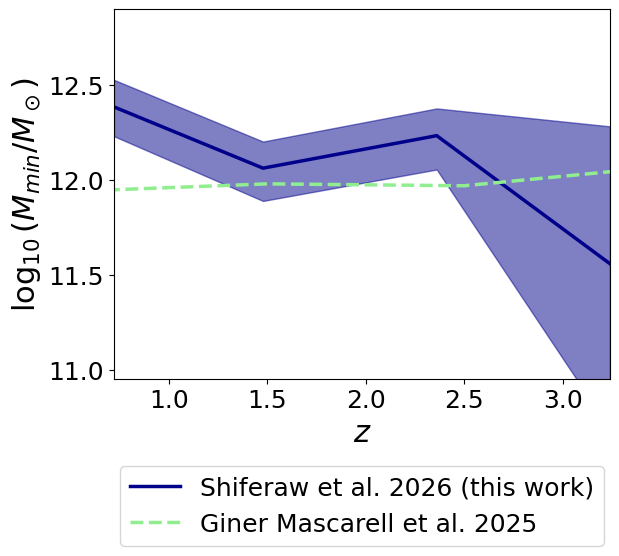

In [182]:
# M_min_lo, M_min_hi = np.array(err['log10(M_min)'])[:,0], np.array(err['log10(M_min)'])[:,1]
plt.plot(zbin, M_min, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, M_min_lo, M_min_hi, alpha = 0.5, color = 'darkblue')
plt.plot(z_eff, M_min_array, label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
# plt.fill_between(zbin, [11.94]*len(zbin), [12.07]*len(zbin), alpha = 0.5, label = 'Giner Mascarell et al. 2025', color = 'lightgreen')
plt.ylabel('$\log_{10}(M_{min}/M_\odot)$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(10.95,12.9)
plt.show()

In [183]:
# f_duty_giner = [0.001986832927349008, 0.001968631474455283, 0.002978657298062041, 0.001968631474455283]

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_247429/2999220170.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$\log_{10}(f_{duty})$')


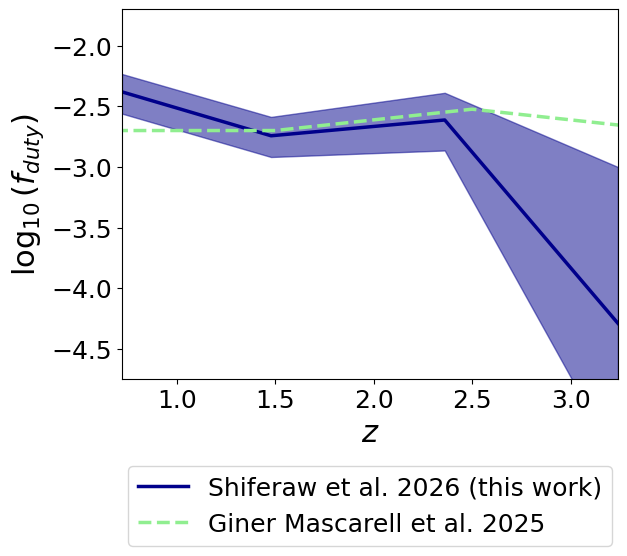

In [184]:
f_duty_lo, f_duty_hi = np.array(err['log10(f_duty)'])[:,0], np.array(err['log10(f_duty)'])[:,1]
plt.plot(zbin, f_duty, color = 'darkblue', linewidth = 2.5, label = 'Shiferaw et al. 2026 (this work)')
plt.fill_between(zbin, f_duty_lo, f_duty_hi, alpha = 0.5, color = 'darkblue')
plt.plot(z_eff, np.log10(fduty), label = 'Giner Mascarell et al. 2025', color = 'lightgreen', linewidth = 2.5, linestyle = '--')
plt.ylabel('$\log_{10}(f_{duty})$')
plt.xlabel('$z$')
plt.legend(bbox_to_anchor = (0.5, -0.2), loc='upper center')
plt.xlim(zbin[0], zbin[-1])
plt.ylim(-4.75,-1.7)
plt.show()

In [185]:
b_eff_wp20 = np.load('../results/b_eff_wp20_planck18.npy')

## Pick cosmology

In [186]:
cosmo = 'Planck'

<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_247429/4052845925.py:62: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


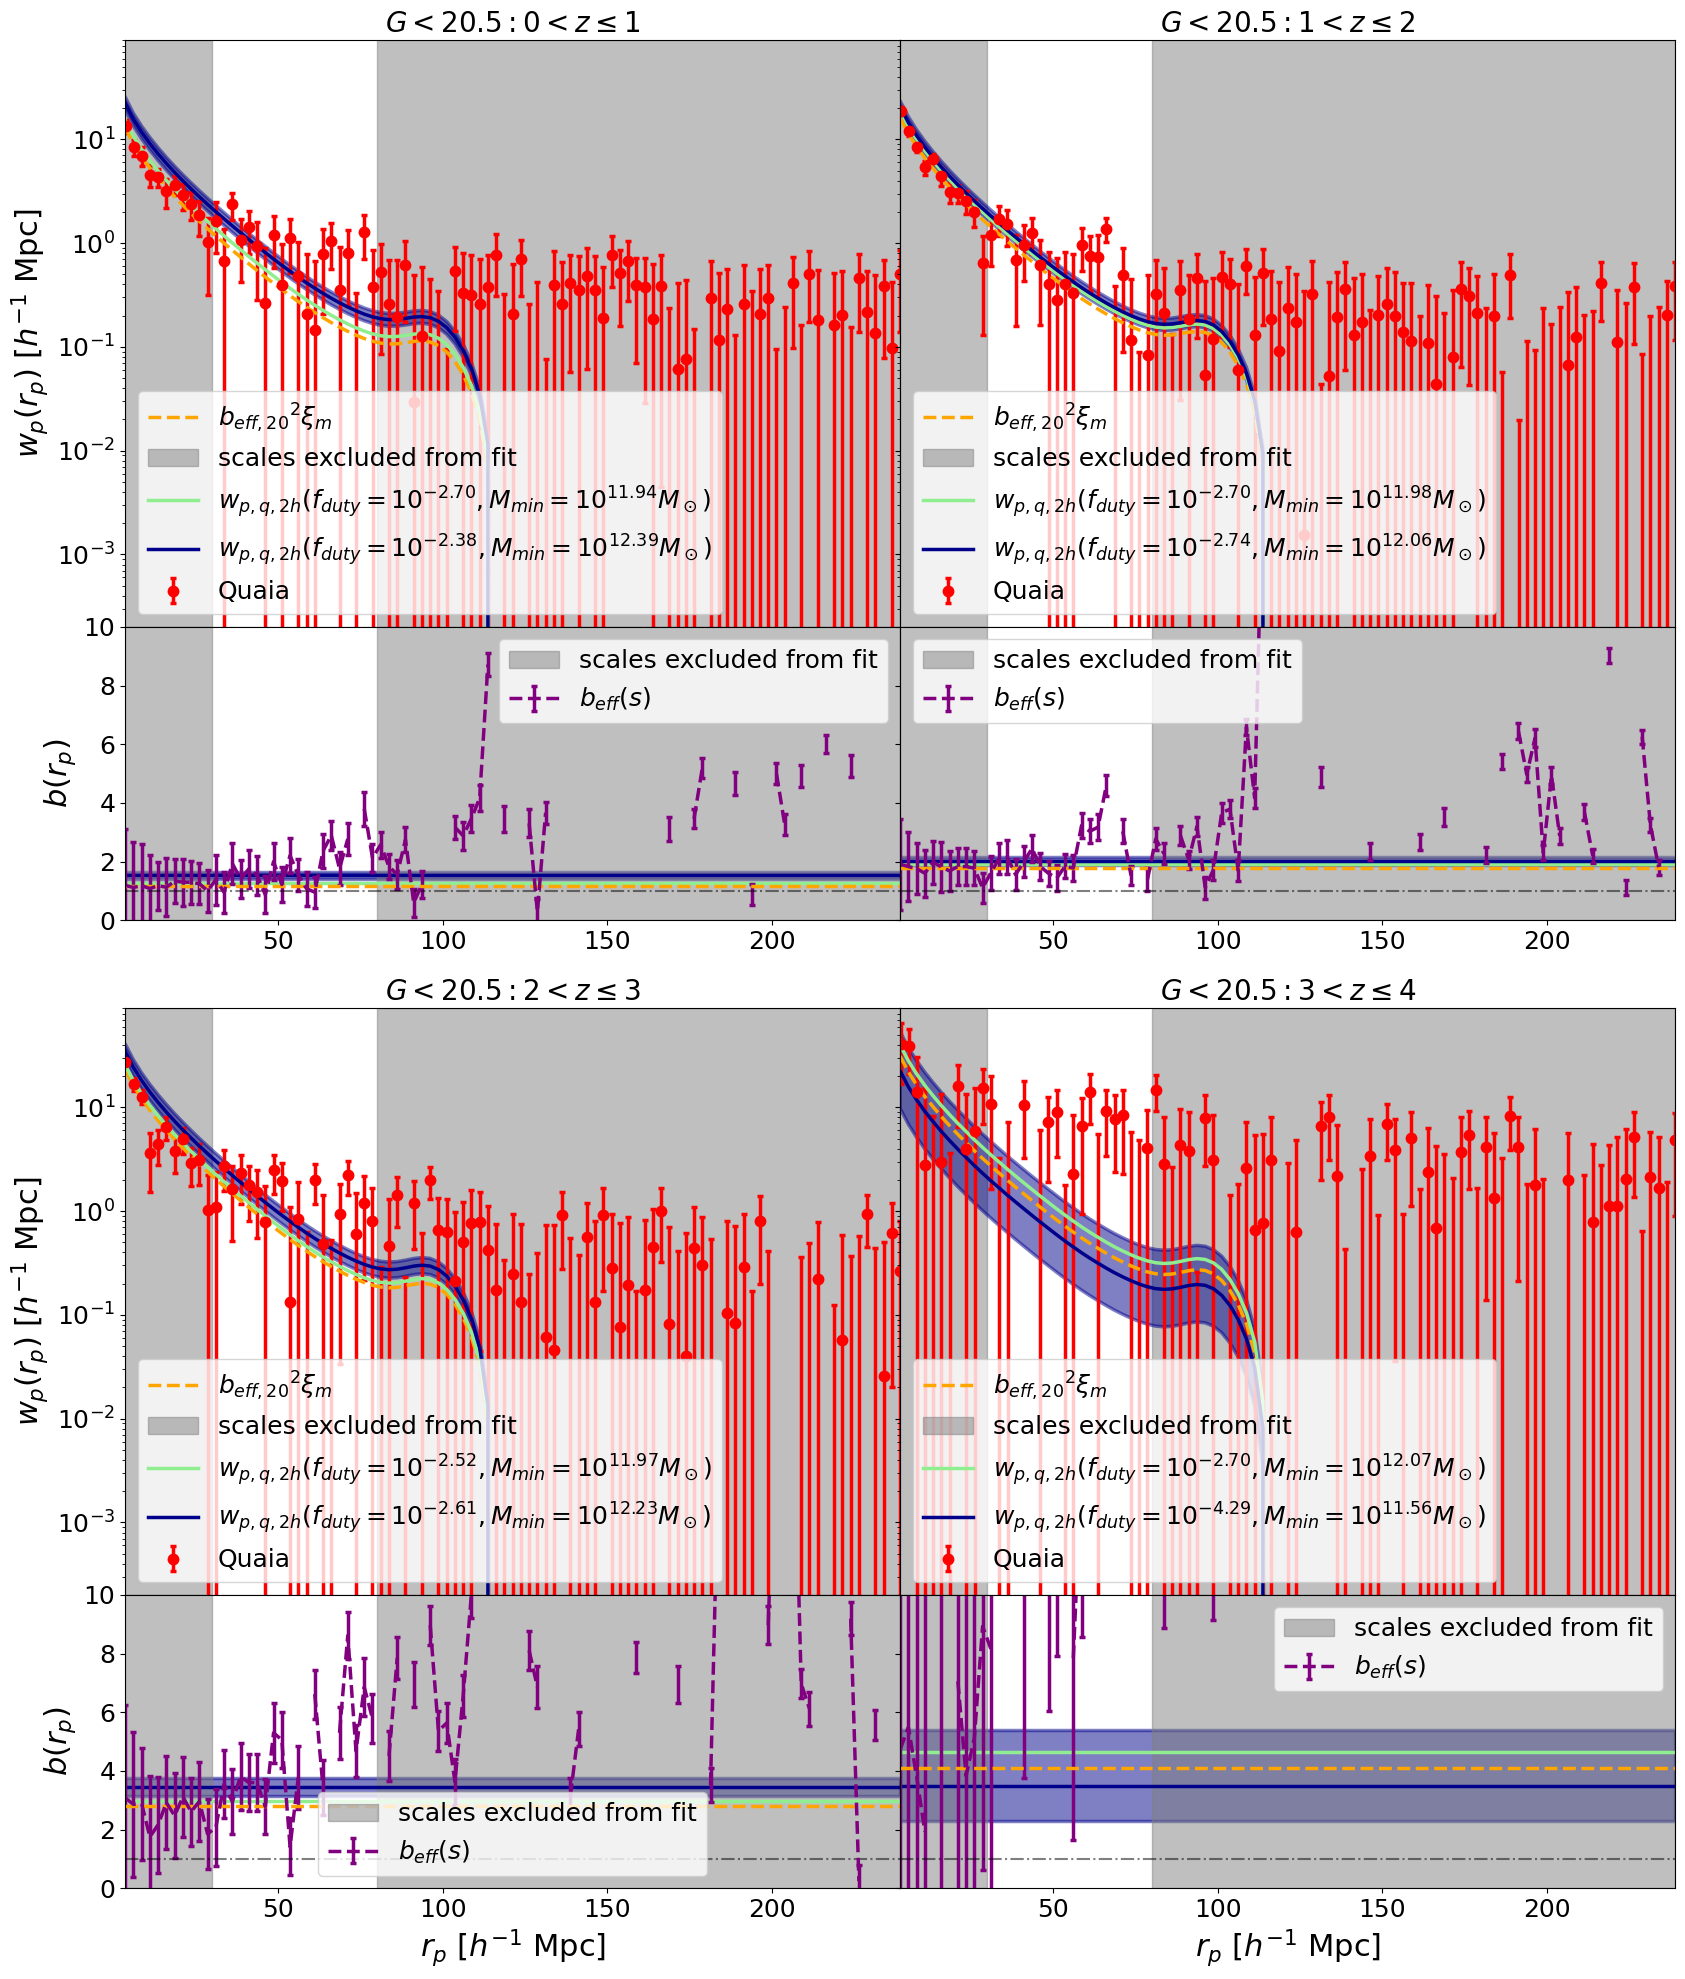

In [187]:
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(5, 2, height_ratios = [1, 0.5, 0.15, 1, 0.5], hspace = 0, wspace = 0)
ylim = 2e-4, 9e1

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+k])
    ax2 = fig.add_subplot(gs[j+k+2])
    
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, j)) # good
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck_MC.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
   
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.plot(quaia.recenter(rbins), b_eff_wp20[j]**2*wp_matter_chi2[j], linewidth = 2.5,
             label = r'${b_{eff, 20}}^2\xi_m$', color = 'orange', linestyle = '--')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                      alpha = 0.5)

    # old fit
    wp_2h_zbin, b_q = wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)
    ax1.plot(quaia.recenter(rbins), wp_2h_zbin, linewidth = 2.5, 
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(np.log10(fduty[j]), M_min_array[j]),
             color = 'lightgreen')
    ax2.axhline(b_q, linewidth = 2.5, color = 'lightgreen')

    # plot new fit
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    
    wp_2h_samples, b_q_samples=[], []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        wp_2h_sample, b_q_sample = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
        b_q_samples.append(b_q_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    b_q_16, b_q_50, b_q_84 = np.percentile(b_q_samples, [16, 50, 84])

    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')
    ax2.axhline(b_q, linewidth = 2.5, color = 'darkblue')
    ax2.fill_between(quaia.recenter(rbins), [b_q_16]*nbins, [b_q_84]*nbins, linewidth = 2.5, color = 'darkblue', alpha = 0.5)
    
    ax2.errorbar(quaia.recenter(rbins), b_wp_chi2[j], linewidth = 2.5, linestyle = '--', markeredgewidth = 2.5, capsize = 2.5,
                 color = 'purple', yerr = np.sqrt(np.diag(C)), label = '$b_{eff}(s)$')
    ax2.axhline(b_eff_wp20[j], linewidth = 2.5, color = 'orange', linestyle = '--')
    ax2.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax2.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                      alpha = 0.5)
    
    if (j + k) % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_xticklabels([])
    ax1.set_ylim(ylim)
    ax1.legend()

    ax2.axhline(1, linestyle = '-.', color = 'black', alpha = 0.5)
    ax2.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax2.set_ylim(0, 10)
    ax2.legend()
    
    if (j+k) % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')
        ax2.set_ylabel(r'$b(r_p)$')

    else:
        ax1.set_yticklabels([])
        ax2.set_yticklabels([])

    if k != 0:
        ax2.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=4

plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_247429/3329604522.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


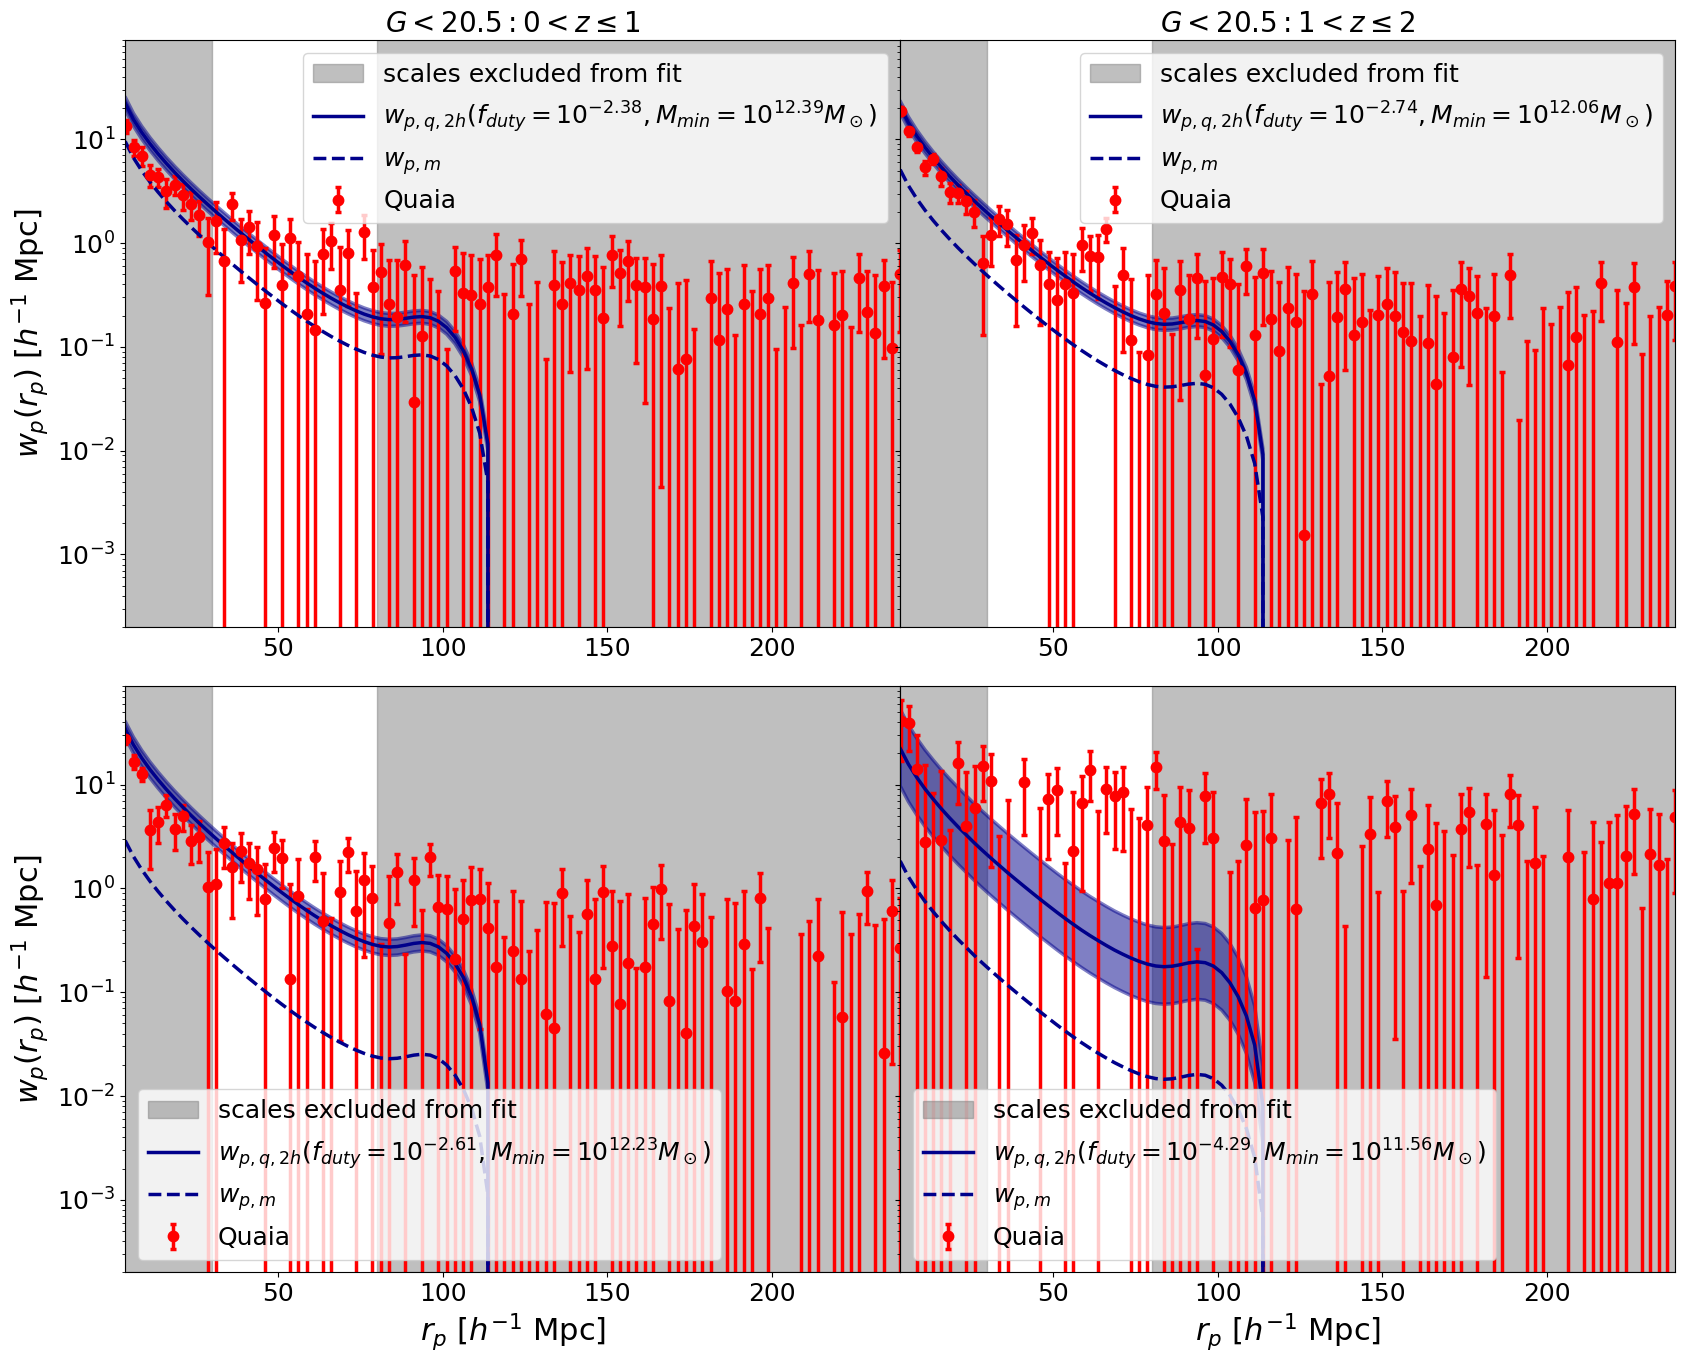

In [188]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.1, wspace = 0)

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck_MC.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
    
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, j))
           
    ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
                yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')
    ax1.plot(quaia.recenter(rbins), wp_matter_chi2[j], linewidth = 2.5,
             label = r'$w_{{p,m}}$', linestyle = '--', 
             color = 'darkblue')

    wp_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        wp_2h_sample, _ = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    

    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(ylim)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j % 2 != 0:
        k+=2

plt.show()

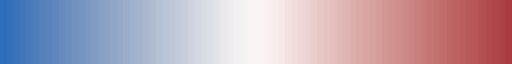

In [189]:
cmap_M_min = sns.color_palette("vlag", n_colors = len(bins))
palette_M_min = matplotlib.colors.ListedColormap(cmap_M_min)
palette_M_min

<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:63: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_247429/3379976324.py:44: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
/tmp/ipykernel_247429/3379976324.py:63: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


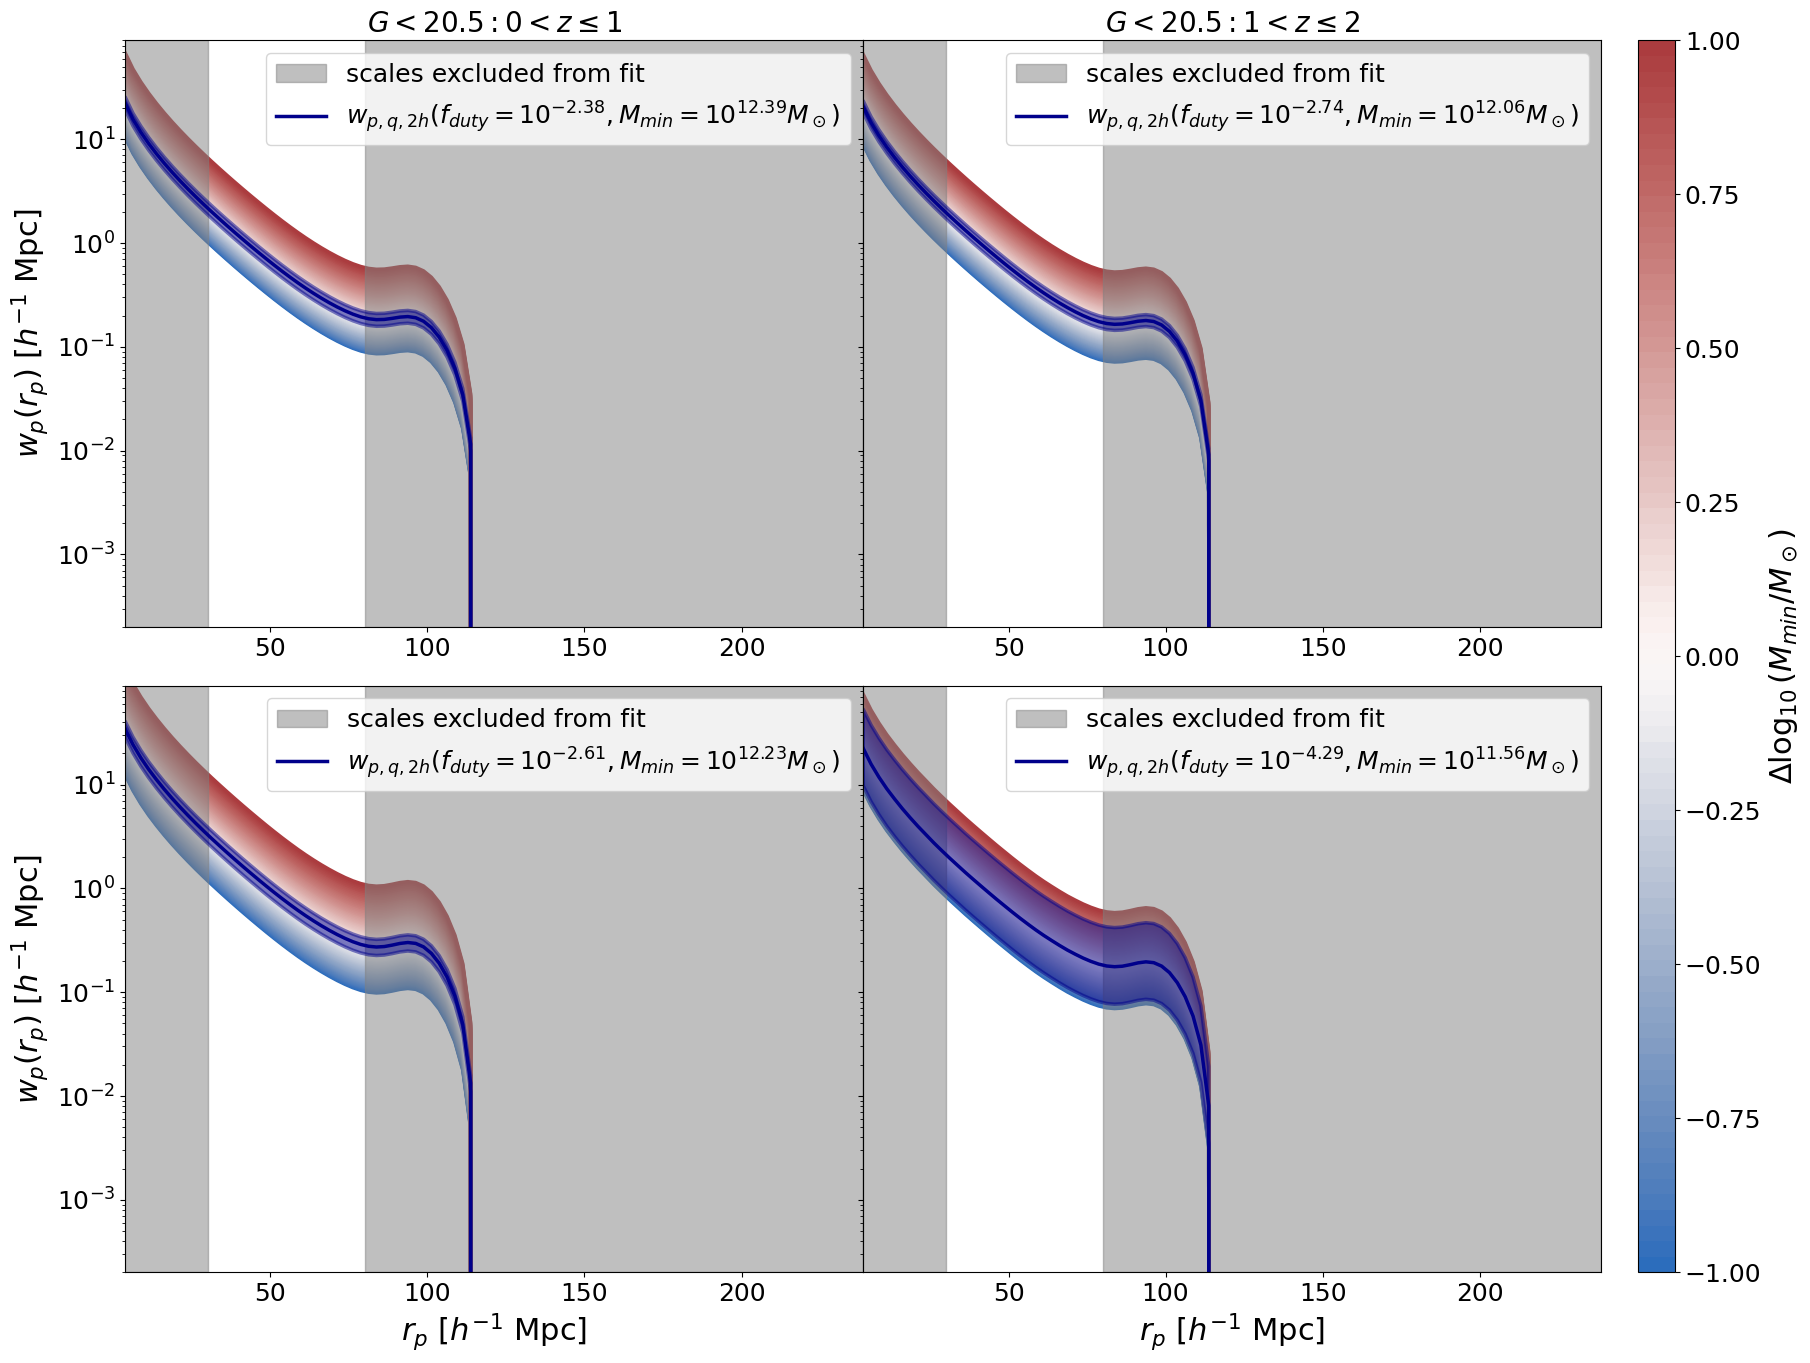

In [190]:
# remove bottom panel and just print bq somewhere
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 4, hspace = 0.1, wspace = 0, width_ratios = [1,1,0.05,0.05])

l = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j+l])
    
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_z{:.1f}_N25_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, j))
    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N120_Planck.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1])) # good
           
    # ax1.errorbar(rpavg_chi2[j], wp_chi2[j], linewidth = 2.5, marker = 'o', label = r'Quaia', color = 'red',
    #             yerr = np.sqrt(np.diag(C)), markeredgewidth = 2.5, capsize = 2.5, linestyle = 'none')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = quaia.recenter(rbins)[0], x2 = 30, color = 'grey', 
                      alpha = 0.5, label = 'scales excluded from fit')
    ax1.fill_betweenx(np.linspace(ylim[0], ylim[1]), x1 = 80, x2 = quaia.recenter(rbins)[-1], color = 'grey', 
                      alpha = 0.5)

    # plot new fit
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    wp_2h_zbin, b_q = wp_2h(np.logspace(M_min[j],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                            recenter = False)
    ax1.plot(quaia.recenter(rbins), wp_2h_zbin, linewidth = 2.5,
             label = r'$w_{{p,q,2h}}(f_{{duty}}=10^{{{:.2f}}}, M_{{min}}=10^{{{:.2f}}}M_\odot)$'.format(f_duty[j], M_min[j]), 
             color = 'darkblue')

    for k in range(len(bins)):
        wp_2h_sample, _ = wp_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), n_m, a_zbin[j], 
                 cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)
        ax1.plot(quaia.recenter(rbins), wp_2h_sample, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))
        
    wp_2h_samples = []
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*f_duty_samples[j][i]
        wp_2h_sample, _ = wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)
        wp_2h_samples.append(wp_2h_sample)
    wp_2h_16, wp_2h_50, wp_2h_84 = np.percentile(wp_2h_samples, [16, 50, 84], axis=0)
    ax1.fill_between(quaia.recenter(rbins), wp_2h_16, wp_2h_84, linewidth = 2.5, alpha = 0.5,
             color = 'darkblue')    

    if j % 6 < 2:
        ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(ylim)
    ax1.legend()
    
    if j % 2 == 0:
        ax1.set_ylabel(r'$w_p(r_p)$ $[h^{-1}$ Mpc]')

    else:
        ax1.set_yticklabels([])

    if j > 1:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # 
            
    if j == 1:
        l+=2

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [191]:
b_q_percentile = []
for j in z_array:
    b_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        b_q_samples.append(wp_2h(np.logspace(M_min_samples[j][i],M_max,79), n_m, a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
                                recenter = False)[1])
    b_q_percentile.append(np.percentile(b_q_samples, [16, 84]))
b_q_lo, b_q_hi = np.array(b_q_percentile).T

<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_247429/3756207690.py:51: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


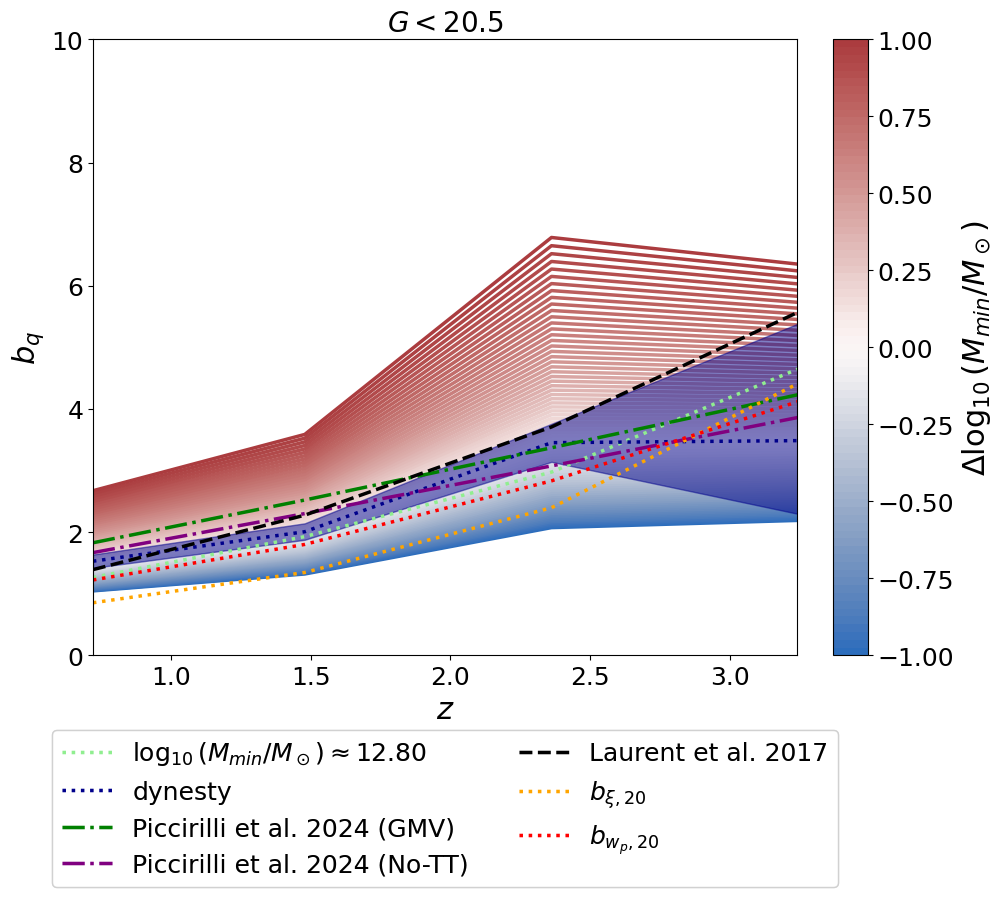

In [192]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
b_q = [wp_2h(bins_M_min[j], n_m_array[j], a_zbin[j], cosmo_planck18, wp_matter_chi2[j], rbins, pibins,
             recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

b_q = [wp_2h(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a_zbin[j], cosmo_planck18, 
             wp_matter_chi2[j], rbins, pibins, recenter = False)[1] for j in z_array]
ax1.plot(zbin, b_q, linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, b_q_lo, b_q_hi, alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

for k in range(len(bins)):
    b_q = [wp_2h(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*f_duty[j], a_zbin[j], 
                 cosmo_planck18, wp_matter_chi2[j], rbins, pibins, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, b_q, linewidth = 2.5, color = cmap_M_min[k], zorder = 0) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.plot(zbin, b_quaia(1.26, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (GMV)', color = 'green') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_quaia(1.15, a_zbin), linestyle = '-.', linewidth = 2.5, 
         label = 'Piccirilli et al. 2024 (No-TT)', color = 'purple') # eq 3.6 in https://arxiv.org/abs/2402.05761
ax1.plot(zbin, b_eboss(zbin), linestyle = '--', linewidth = 2.5, label = 'Laurent et al. 2017', 
         color = 'black') # eq 3.6 in https://arxiv.org/abs/2402.05761

ax1.plot(zbin, b_cf20, linestyle = ':', linewidth = 2.5, label = r'$b_{\xi, 20}$', color = 'orange') 
ax1.plot(zbin, b_wp20, linestyle = ':', linewidth = 2.5, label = '$b_{w_p, 20}$', color = 'red') 

ax1.set_title('$G<{}$'.format(G_hi))

ax1.set_xlabel('$z$')
ax1.set_ylim(0, 10)
ax1.set_xlim(zbin[0], zbin[-1])
ax1.set_ylabel(r'$b_q$')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5),
                Line2D([0], [0], color = 'green', linestyle = '-.', linewidth = 2.5), 
                Line2D([0], [0], color = 'purple', linestyle = '-.', linewidth = 2.5),
                Line2D([0], [0], color = 'black', linestyle = '--', linewidth = 2.5), 
                Line2D([0], [0], color = 'orange', linestyle = ':', linewidth = 2.5), 
                Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Piccirilli et al. 2024 (GMV)', 'Piccirilli et al. 2024 (No-TT)', 
                                          'Laurent et al. 2017', r'$b_{\xi, 20}$', '$b_{w_p, 20}$'], ncol = 2, bbox_to_anchor = (0.5, -0.1), 
                           loc='upper center')
fig.add_artist(second_legend)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [193]:
M_h_percentile = []
for j in z_array:
    M_h_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        M_h_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0])
    M_h_percentile.append(np.percentile(M_h_samples, [16, 84]))
M_h_lo, M_h_hi = np.array(M_h_percentile).T

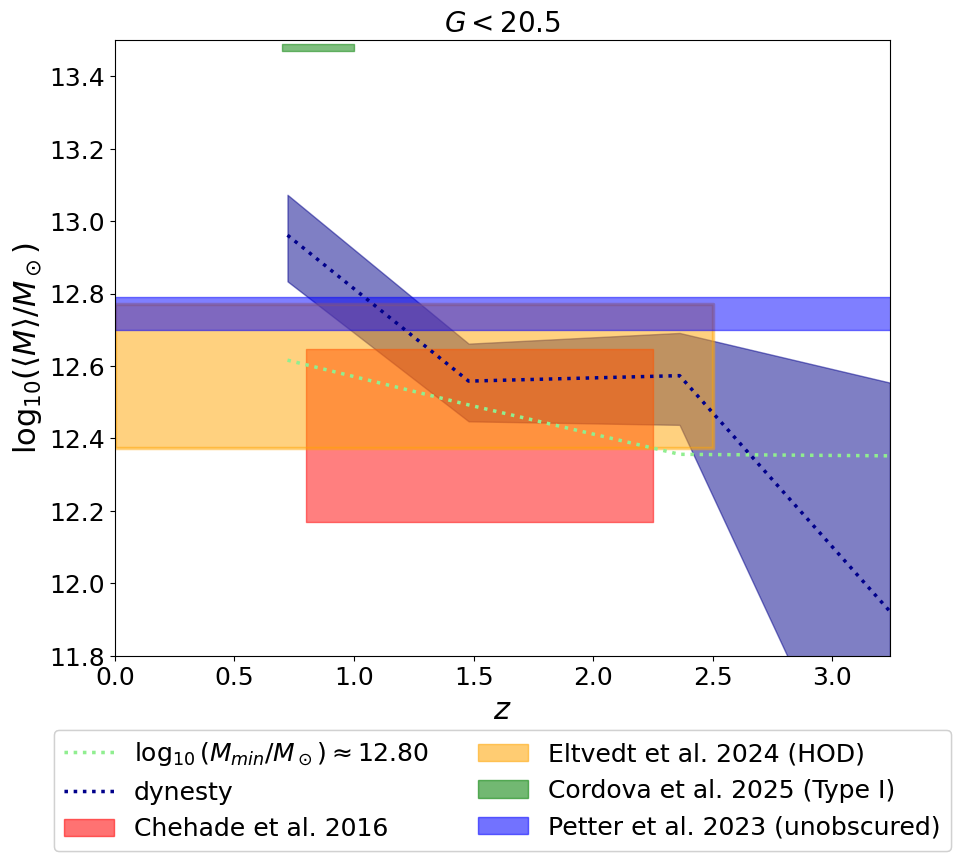

In [194]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 1, wspace = 0)
ax1 = fig.add_subplot(gs[0])
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), 
                # mpatches.Patch(color='lightgreen', alpha = 0.5), 
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [#'Giner Mascarell et al. 2025', 
                                          r'$\log_{{10}}(M_{{min}}/M_\odot)\approx{:.2f}$'.format(12.8), 
                                          'dynesty', 'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.1), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

plt.show()

<>:46: SyntaxWarning: invalid escape sequence '\D'
<>:46: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_247429/1482196861.py:46: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')


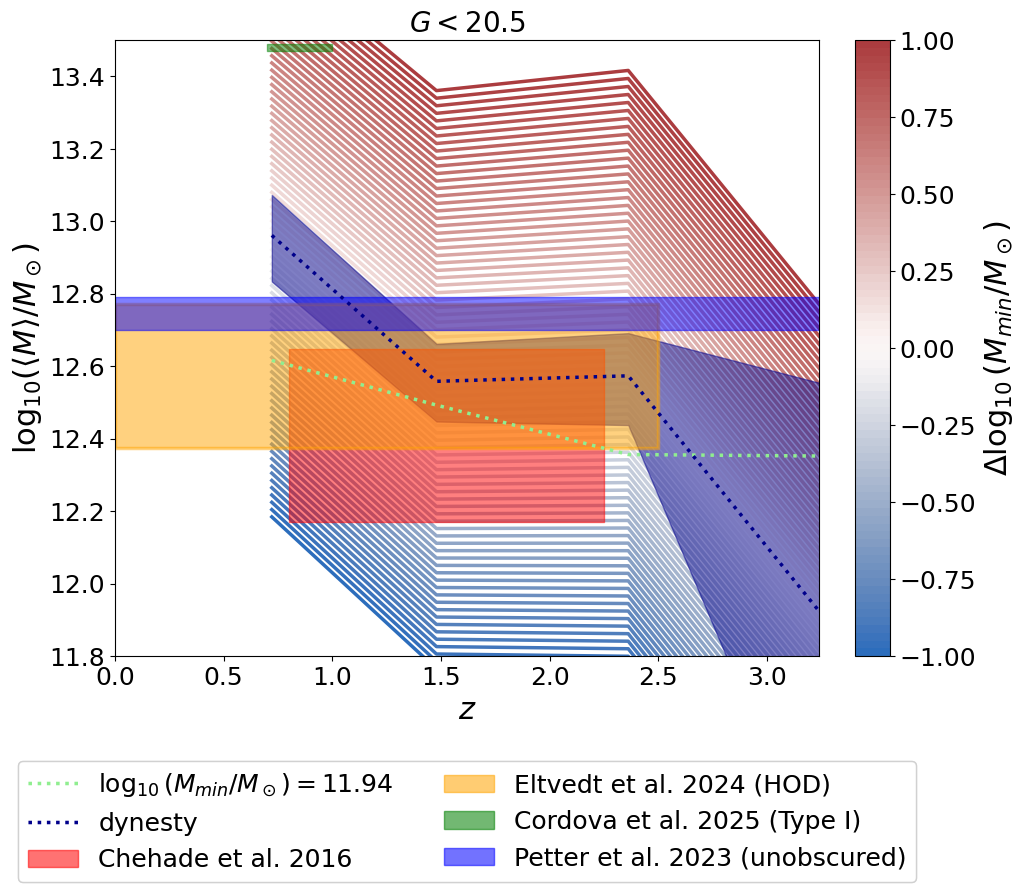

In [195]:
fig = plt.figure(figsize = (10, 8))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(1, 3, width_ratios = [1, 0.05, 0.05], wspace = 0)
ax1 = fig.add_subplot(gs[0])

for k in range(len(bins)):
    
    M_h = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
    ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, 
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:{:.2f} M_\odot$'.format(fduty[0]*100, fduty[-1]*100, np.log10(bins[k])),
             color = cmap_M_min[k], zorder = 0) #, alpha = (1+k)/len(bins))
    
M_h = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[0] for j in z_array]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))

M_h = [M(np.logspace(M_min[j], M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[0] for j in range(len(z_array))]
ax1.plot(zbin, np.log10(M_h), linewidth = 2.5, color = 'darkblue', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(M_h_lo), np.log10(M_h_hi), alpha = 0.5, color = 'darkblue') # color = cmaps[i][j], alpha = (l+1)/len(bins))

z = np.linspace(0.8, 2.25)
ax1.fill_between(z, [np.log10(1e12/Planck18.h)]*len(z), [np.log10(3e12/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Chehade et al. 2016', color = 'red')
ax1.set_title('$G<{}$'.format(G_hi))
ax1.fill_between(np.linspace(0, 2.5), [np.log10(1.6e12/Planck18.h)]*len(z), [np.log10(4e12/Planck18.h)]*len(z), linewidth = 2.5, 
                 label = 'Eltvedt et al. 2024 (HOD)', alpha = 0.5, color = 'orange')
ax1.fill_between(np.linspace(0.7, 1), [13.47]*len(z), [13.49]*len(z), alpha = 0.5, label = 'Cordova et al. 2025 (Type I)', color = 'green')

# check redshift range and check cordova type i was right to include because conflicts with this
ax1.fill_between(np.linspace(0, 3.5), [np.log10(10**12.53/Planck18.h)]*len(z), [np.log10(10**12.62/Planck18.h)]*len(z), alpha = 0.5, 
                 label = 'Petter et al. 2023 (unobscured)', color = 'blue')

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5), mpatches.Patch(color='red', alpha = 0.5), 
                mpatches.Patch(color='orange', alpha = 0.5), mpatches.Patch(color='green', alpha = 0.5), mpatches.Patch(color='blue', alpha = 0.5)]
second_legend = ax1.legend(custom_lines, [r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0]), 'dynesty',
                            'Chehade et al. 2016', 'Eltvedt et al. 2024 (HOD)', 'Cordova et al. 2025 (Type I)', 'Petter et al. 2023 (unobscured)'], 
                           ncol = 2, bbox_to_anchor = (0.5, -0.15), loc='upper center')
fig.add_artist(second_legend)

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(\langle M \rangle/M_\odot)$')
ax1.set_xlim(0, zbin[-1])
ax1.set_ylim(11.8, 13.5)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[:,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
plt.show()

In [196]:
fduty_array = np.logspace(-5,0, 51) #-4

In [197]:
cmap_fduty_k = sns.color_palette("vlag", n_colors = len(fduty_array))

In [198]:
n_q_percentile = []
for j in z_array:
    n_q_samples=[]
    for i in range(len(ind)):
        n_m=np.ones(np.shape(bins))*10**f_duty_samples[j][i]
        n_q_samples.append(M(np.logspace(M_min_samples[j][i], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, 
         recenter = False)[1])
    n_q_percentile.append(np.percentile(n_q_samples, [16, 84]))
n_q_theory_fit_lo, n_q_theory_fit_hi = np.array(n_q_percentile).T

<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_247429/1111811723.py:44: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(M_{min}/M_\odot)$')
/tmp/ipykernel_247429/1111811723.py:77: SyntaxWarning: invalid escape sequence '\D'
  label = '$\Delta \log_{10}(f_{duty})$')


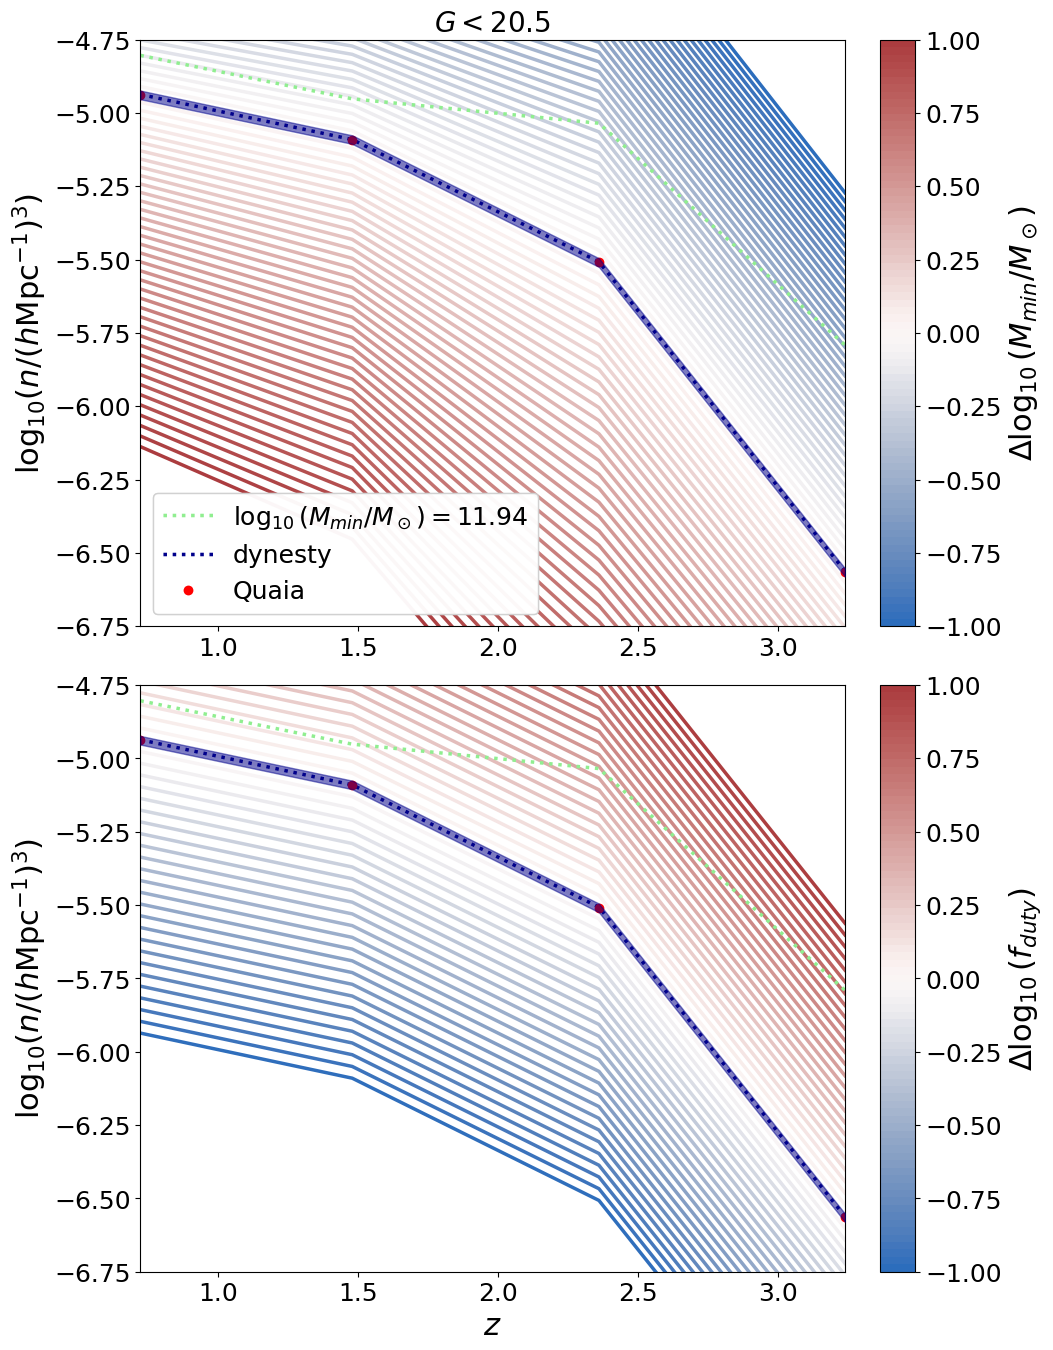

In [199]:
fig = plt.figure(figsize = (10, 16))
labels_cf = ['qq', r'$\xi_{2h}$']
gs = gridspec.GridSpec(2, 3, width_ratios = [1, 0.05, 0.05], wspace = 0, hspace = 0.1)
ax1 = fig.add_subplot(gs[0])
ylim = -6.75, -4.75

for k in range(len(bins)):
    
    n_q_theory = [M(np.logspace(M_min[j]-1+k/int(len(bins)/2), M_max, 79), np.ones(np.shape(bins))*10**f_duty[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             label = r'$f_{{duty}}: {:.2f}\%-{:.2f}\%, M_{{min}}:[{:.2f}-{:.2f}] M_\odot$'.format(f_duty[0]*100, f_duty[-1]*100, np.log10(bins[0]), 
                                                                                                  np.log10(bins[-1])), color = cmap_M_min[k])
    
n_q_theory, n_q_theory_fit = [], [] #, n_q_theory_fit_lo, n_q_theory_fit_hi = [], [], [], []
for j in z_array:
    
    n_q_theory.append(M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
    
    n_m=np.ones(np.shape(bins))*10**f_duty[j]
    n_q_theory_fit.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])

ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'$\chi^2$ minimization') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, label = r'$\chi^2$ minimization', zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_title('$G<{}$'.format(G_hi))
ax1.set_xlim(zbin[0], zbin[-1])

custom_lines = [Line2D([0], [0], color = 'lightgreen', linestyle = ':', linewidth = 2.5, 
                       label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])),
                Line2D([0], [0], color = 'darkblue', linestyle = ':', linewidth = 2.5, 
                       label = 'dynesty'), 
                Line2D([0], [0], color = 'red', marker = 'o', linestyle = 'None', linewidth = 2.5, label = 'Quaia')]
second_legend = ax1.legend(handles = custom_lines)
fig.add_artist(second_legend)

# ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[0,-1]), 
                    label = '$\Delta \log_{10}(M_{min}/M_\odot)$')

ax1 = fig.add_subplot(gs[3])
i = 1
l = 38

for k in range(len(fduty_array)):

    n_q_theory=[]
    for j in z_array:
        
        n_m = np.ones(np.shape(bins))*10**(f_duty[j]-1+k/int(len(fduty_array)/2))
        n_q_theory.append(M(np.logspace(M_min[j], M_max, 79), n_m, a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1])
        
    ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, #alpha = (1+k)/len(bins),
             color = cmap_fduty_k[k])
    
n_q_theory = [M(bins_M_min[j], n_m_array[j], a = a_zbin[j], cosmo = cosmo_planck18, recenter = False)[1] for j in z_array]
ax1.plot(zbin, np.log10(n_q_theory), linewidth = 2.5, color = 'lightgreen', linestyle = ':', 
         label = r'$\log_{{10}}(M_{{min}}/M_\odot)={:.2f}$'.format(M_min_array[0])) # color = cmaps[i][j], alpha = (l+1)/len(bins)) np.log10(bins[l])

ax1.plot(zbin, np.log10(n_q_theory_fit), linewidth = 2.5, color = 'darkblue', linestyle = ':', label = r'dynesty') # color = cmaps[i][j], alpha = (l+1)/len(bins))
ax1.fill_between(zbin, np.log10(n_q_theory_fit_lo), np.log10(n_q_theory_fit_hi), color = 'darkblue', alpha = 0.5, zorder = 3) # color = cmaps[i][j], alpha = (l+1)/len(bins))

ax1.errorbar(zbin, np.log10(n_q), linewidth = 2.5, marker = 'o', label = 'Quaia', color = 'red',
             yerr = [np.log10(n_q)-np.log10(np.subtract(n_q, n_q_err)), np.log10(np.add(n_q, n_q_err))-np.log10(n_q)], linestyle = 'None')

ax1.set_xlabel('$z$')
ax1.set_ylabel(r'log$_{10}(n/(h\mathrm{Mpc}^{-1})^3)$')
ax1.set_ylim(ylim)
ax1.set_xlim(zbin[0], zbin[-1])

cbar = fig.colorbar(cm.ScalarMappable(cmap=palette_M_min, norm = matplotlib.colors.Normalize(vmin=-1, vmax = 1)), cax = fig.add_subplot(gs[1,-1]), 
                    label = '$\Delta \log_{10}(f_{duty})$')
plt.show()